# Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reading the dataset

In [ ]:
data = pd.read_csv('/content/Preprocessed_dataset_knn(5neighbour).csv')
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


In [ ]:
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


# Dataset inspection

In [ ]:
data.shape

(51867, 22)

In [ ]:
data.dtypes

,0
Project County,object
Project City,object
Gas Utility,object
Electric Utility,object
Total Project Cost,float64
Pre-Retrofit Home Heating Fuel Type,object
Year Home Built,int64
Size Of Home,int64
Number Of Units,int64
Job Type,object


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51867 entries, 0 to 51866
Data columns (total 22 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Project County                                        51867 non-null  object 
 1   Project City                                          51867 non-null  object 
 2   Gas Utility                                           51867 non-null  object 
 3   Electric Utility                                      51867 non-null  object 
 4   Total Project Cost                                    51867 non-null  float64
 5   Pre-Retrofit Home Heating Fuel Type                   51867 non-null  object 
 6   Year Home Built                                       51867 non-null  int64  
 7   Size Of Home                                          51867 non-null  int64  
 8   Number Of Units                                       51

In [ ]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


In [ ]:
data[data['First Year Modeled Project Energy Savings $ Estimate'].isna()]

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home


# Dropping null values as the number of null values is less than 1%

In [ ]:
data = data.dropna()

In [ ]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


# Building new feature columns and dropping the existing once to solve for multicolinearity

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home'],
      dtype='object')

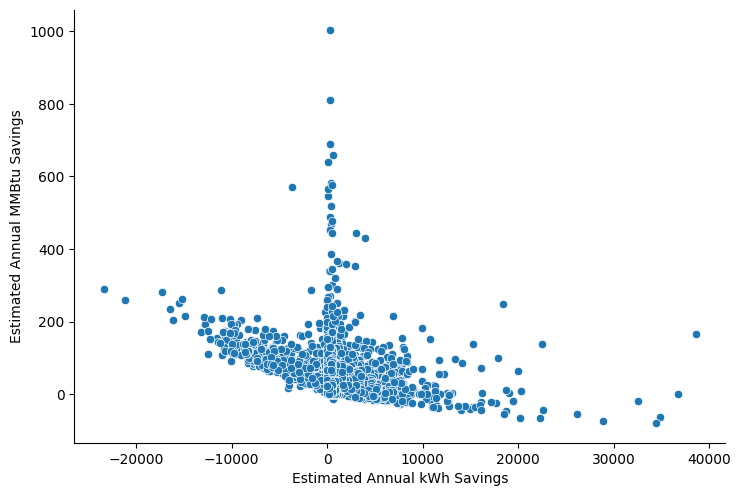

In [ ]:
x = data['Estimated Annual kWh Savings']
y = data['Estimated Annual MMBtu Savings']
sns.pairplot(data, x_vars=['Estimated Annual kWh Savings'], y_vars=['Estimated Annual MMBtu Savings'], height=5, aspect=1.5)

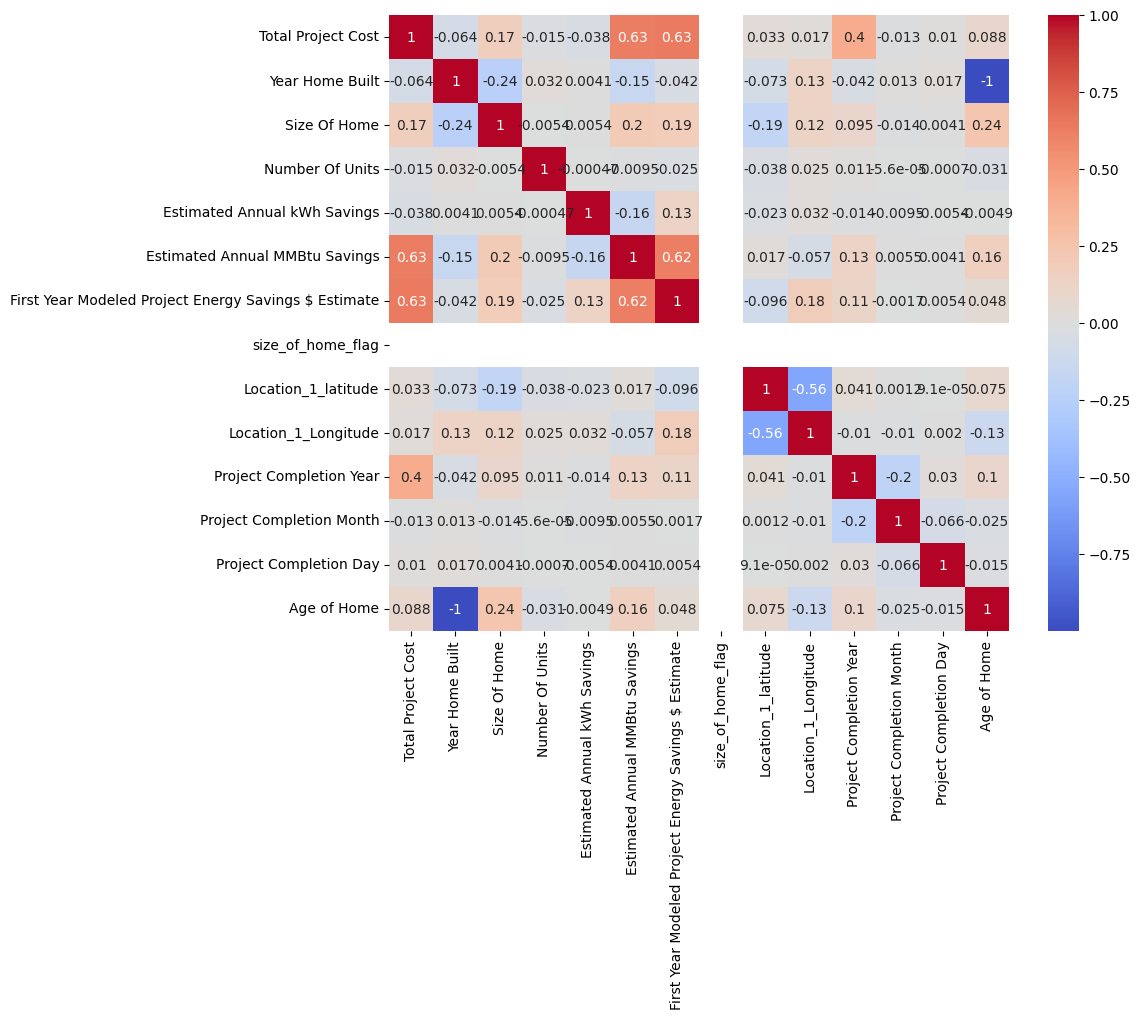

In [ ]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[num_col].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Findings
1. Project zip is not a numerical column, its a categorical data since its location has different zip code, therefore this correlation is artificial created
   a. Either remove zipcode
   b. Encode the project zipcode
2. Total Project Cost has strong positive correlation with:
        Estimated Annual MMBtu Savings (+0.63)
        First-Year Energy Savings ($) (+0.63)
    This suggests that higher investments lead to higher energy and monetary savings.
3. Estimated MMBtu Savings and Project Cost are strongly correlated with the target variable (~0.62–0.63), indicating possible redundancy or leakage. These features should be carefully evaluated before modeling.

# Age of house

In [ ]:
data['Year Home Built'].value_counts()

,count
Year Home Built,
1921,2018
1941,1660
1951,1261
1961,1218
1971,1039
...,...
1813,1
1812,1
1818,1


In [ ]:
data['Project Completion Year'].value_counts()

,count
Project Completion Year,
2022,10050
2019,9367
2021,8789
2018,8565
2023,8316
2020,6780


## Findings
since the year built gives us when the house was built which is static datapoint, we need to understand that how old the building was when it was retrofitted to understand the nature of the house because the energy efficiency depends on the age of building rather than the when it was built.
<br>
Assumption:
1. older homes -> poor insulation -> High savings potential post retrofit
2. newer homes -> well insulated -> low savings potential post retrofit

In [ ]:
data['Age of Home'] = data['Project Completion Year'] - data['Year Home Built']
data['Age of Home'].describe()

,Age of Home
count,51867.000000
mean,72.443326
std,29.468805
min,0.000000
25%,54.000000
50%,73.000000
75%,90.000000
max,233.000000


# Normalisation of data points

## Project cost

In [ ]:
data['Total Project Cost'].describe()

,Total Project Cost
count,51867.000000
mean,6435.772476
std,4154.958606
min,129.000000
25%,3746.000000
50%,5929.000000
75%,8466.000000
max,92297.000000


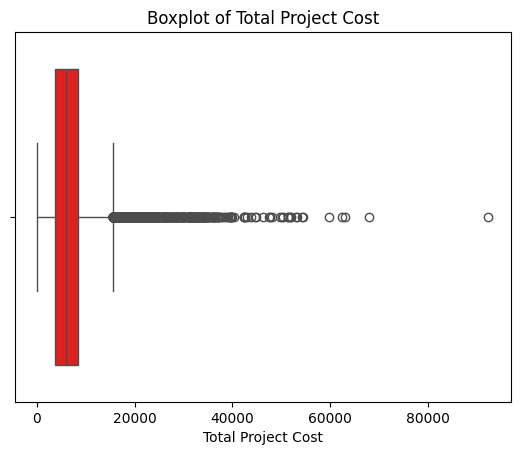

In [ ]:
sns.boxplot(x=data['Total Project Cost'], color='red')
plt.title('Boxplot of Total Project Cost')
plt.show()

### Finding

Using summary statistics and boxplot visualization, there is a significant gap between the 75th percentile and the maximum value, indicating the presence of extreme high value observations. This suggests that the distribution is right skewed, where a small number of large project costs extend the upper tail.

Such skewness can adversely affect linear models, as they are sensitive to extreme values, potentially leading to biased coefficient estimates and reduced predictive performance.

In [ ]:
data['Cost_per_Sqft'] = data['Total Project Cost'] / data['Size Of Home']
data['Cost_per_Sqft'].describe()


,Cost_per_Sqft
count,51867.000000
mean,4.485980
std,3.108841
min,0.089583
25%,2.302809
50%,3.963024
75%,6.038481
max,44.664000


In [ ]:
data['Size Of Home'].value_counts()

,count
Size Of Home,
800,2545
924,717
980,686
1200,514
4000,507
...,...
2877,1
3327,1
3477,1


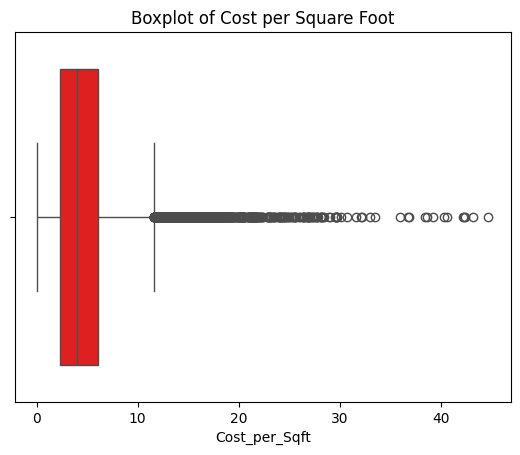

In [ ]:
sns.boxplot(x=data['Cost_per_Sqft'], color='red')
plt.title('Boxplot of Cost per Square Foot')
plt.show()

In [ ]:
data['log_cost_per_Sqft'] = np.log(data['Cost_per_Sqft'] + 1)  # Adding 1 to avoid log(0)
data['log_cost_per_Sqft'].describe()

,log_cost_per_Sqft
count,51867.000000
mean,1.553283
std,0.558052
min,0.085795
25%,1.194773
50%,1.602015
75%,1.951392
max,3.821310


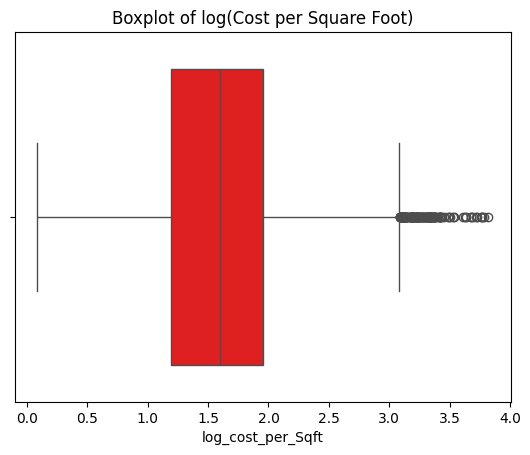

In [ ]:
sns.boxplot(x=data['log_cost_per_Sqft'], color='red')
plt.title('Boxplot of log(Cost per Square Foot)')
plt.show()

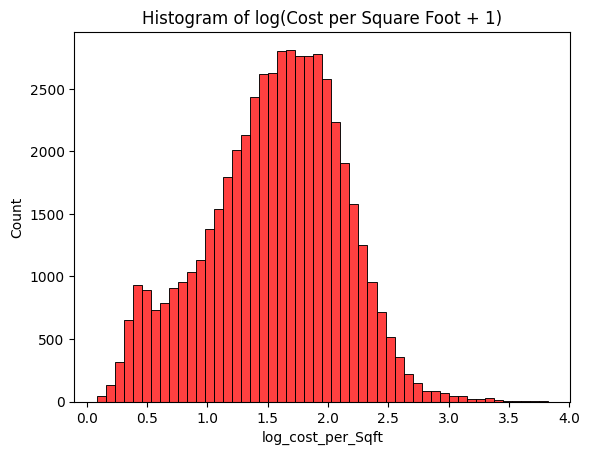

In [ ]:
sns.histplot(x=data['log_cost_per_Sqft'], color='red', bins=50)
plt.title('Histogram of log(Cost per Square Foot + 1)')
plt.show()

In [ ]:
data.rename(columns={'First Year Modeled Project Energy Savings $ Estimate': 'Log_Annual_Savings_Estimate_in_$'}, inplace=True)
data.drop(columns="Cost_per_Sqft", inplace=True)

## Estimated Annual kWh Savings

In [ ]:
data['Estimated Annual kWh Savings'].describe()

,Estimated Annual kWh Savings
count,51867.000000
mean,470.110186
std,1095.896135
min,-23368.000000
25%,158.000000
50%,443.000000
75%,536.000000
max,38572.000000


### Findings

The presence of negative values in Estimated Annual kWh Savings indicates that, for some projects, the modeled post retrofit energy consumption is higher than pre retrofit levels. these projects are estimated to increase energy usage rather than reduce it.

Assumptions:
1. Higher energy usage post retrofit
2. System change in heating type like gas -> electric or other type of heating

  *The Estimated Annual kWh Savings variable contains negative values, indicating that certain retrofit projects are associated with increased electricity consumption. This may arise due to behavioral changes, fuel switching, or modeling uncertainty. These values are retained as they provide meaningful insights into project performance rather than representing data errors.*

<Axes: xlabel='Estimated Annual kWh Savings', ylabel='Count'>

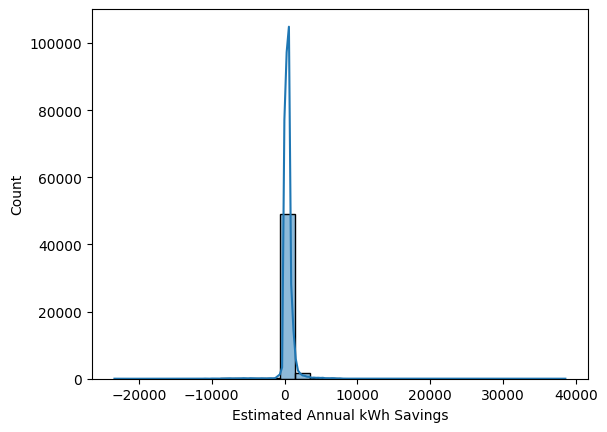

In [ ]:
sns.histplot(data['Estimated Annual kWh Savings'], bins=30, kde=True)

In [ ]:
data['kWh_savings_per_Sqft'] = data['Estimated Annual kWh Savings'] / data['Size Of Home']

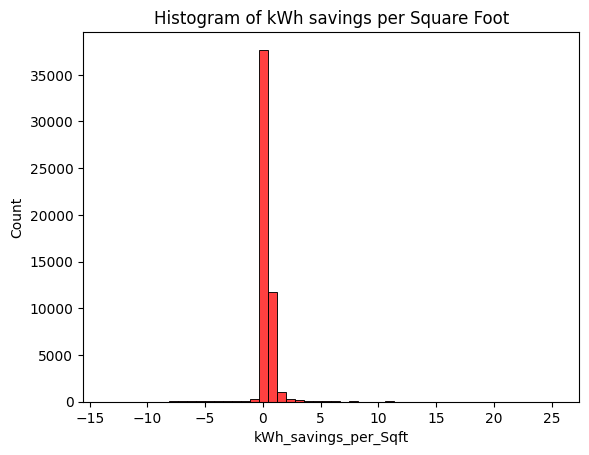

In [ ]:
sns.histplot(x=data['kWh_savings_per_Sqft'], color='red', bins=50)
plt.title('Histogram of kWh savings per Square Foot')
plt.show()

## Estimate annual MMBtu savings per sqft

In [ ]:
data['Estimated Annual MMBtu Savings'].describe()

,Estimated Annual MMBtu Savings
count,51867.000000
mean,31.401238
std,27.033473
min,-80.000000
25%,14.000000
50%,26.000000
75%,43.000000
max,1005.000000


### Findings

The MMBtu savings per square foot variable contains both positive and negative values, indicating variability in retrofit effectiveness. Due to the presence of negative values and extreme outliers, log transformation was not appropriate. Instead, the feature was retained in its original scale with outlier capping applied to stabilize the distribution.

In [ ]:
data['MMBtu_savings_per_Sqft'] = data['Estimated Annual MMBtu Savings'] / data['Size Of Home']

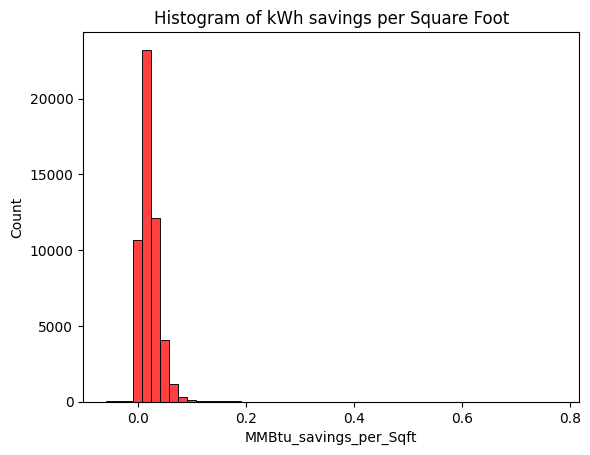

In [ ]:
sns.histplot(x=data['MMBtu_savings_per_Sqft'], color='red', bins=50)
plt.title('Histogram of kWh savings per Square Foot')
plt.show()

## Converting the MMBtu savings to kWh savings and merging with electric savings to get a new field called Total_energy_savings

In [ ]:
data['total_energy_savings_kwh'] = (
    data['Estimated Annual kWh Savings'] +
    data['Estimated Annual MMBtu Savings'] * 293.071
)

In [ ]:
data['total_energy_savings_kwh'].describe()

,total_energy_savings_kwh
count,51867.000000
mean,9672.902343
std,7820.263511
min,-3239.923000
25%,4612.994000
50%,8261.846000
75%,13045.053000
max,294805.355000


In [ ]:
data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh'] / data['Size Of Home']
data['total_energy_savings_kwh_sqft'].describe()

,total_energy_savings_kwh_sqft
count,51867.000000
mean,6.595226
std,5.332354
min,-2.225222
25%,3.032571
50%,5.621704
75%,9.024491
max,227.473268


In [ ]:
q1 = data['total_energy_savings_kwh_sqft'].quantile(0.01)
q99 = data['total_energy_savings_kwh_sqft'].quantile(0.99)

data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh_sqft'].clip(q1, q99)

In [ ]:
data['total_energy_savings_kwh'].describe()

,total_energy_savings_kwh
count,51867.000000
mean,9672.902343
std,7820.263511
min,-3239.923000
25%,4612.994000
50%,8261.846000
75%,13045.053000
max,294805.355000


### Tasks performed

A combined energy savings feature was constructed by converting MMBtu savings into kWh equivalents. This aggregated measure was further normalized by home size to derive energy savings per square foot, capturing efficiency across properties of varying sizes. Outlier treatment was applied to stabilize the distribution and improve model robustness.

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings', 'Log_Annual_Savings_Estimate_in_$',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'kWh_savings_per_Sqft', 'MMBtu_savings_per_Sqft',
       'total_energy_savings_kwh', 'total_energy_savings_kwh_sqft'],
      dtype='object')

In [ ]:
data.drop(columns=['Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings','total_energy_savings_kwh'], inplace=True)

# Heatmap post feature extraction

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Log_Annual_Savings_Estimate_in_$',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'kWh_savings_per_Sqft', 'MMBtu_savings_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

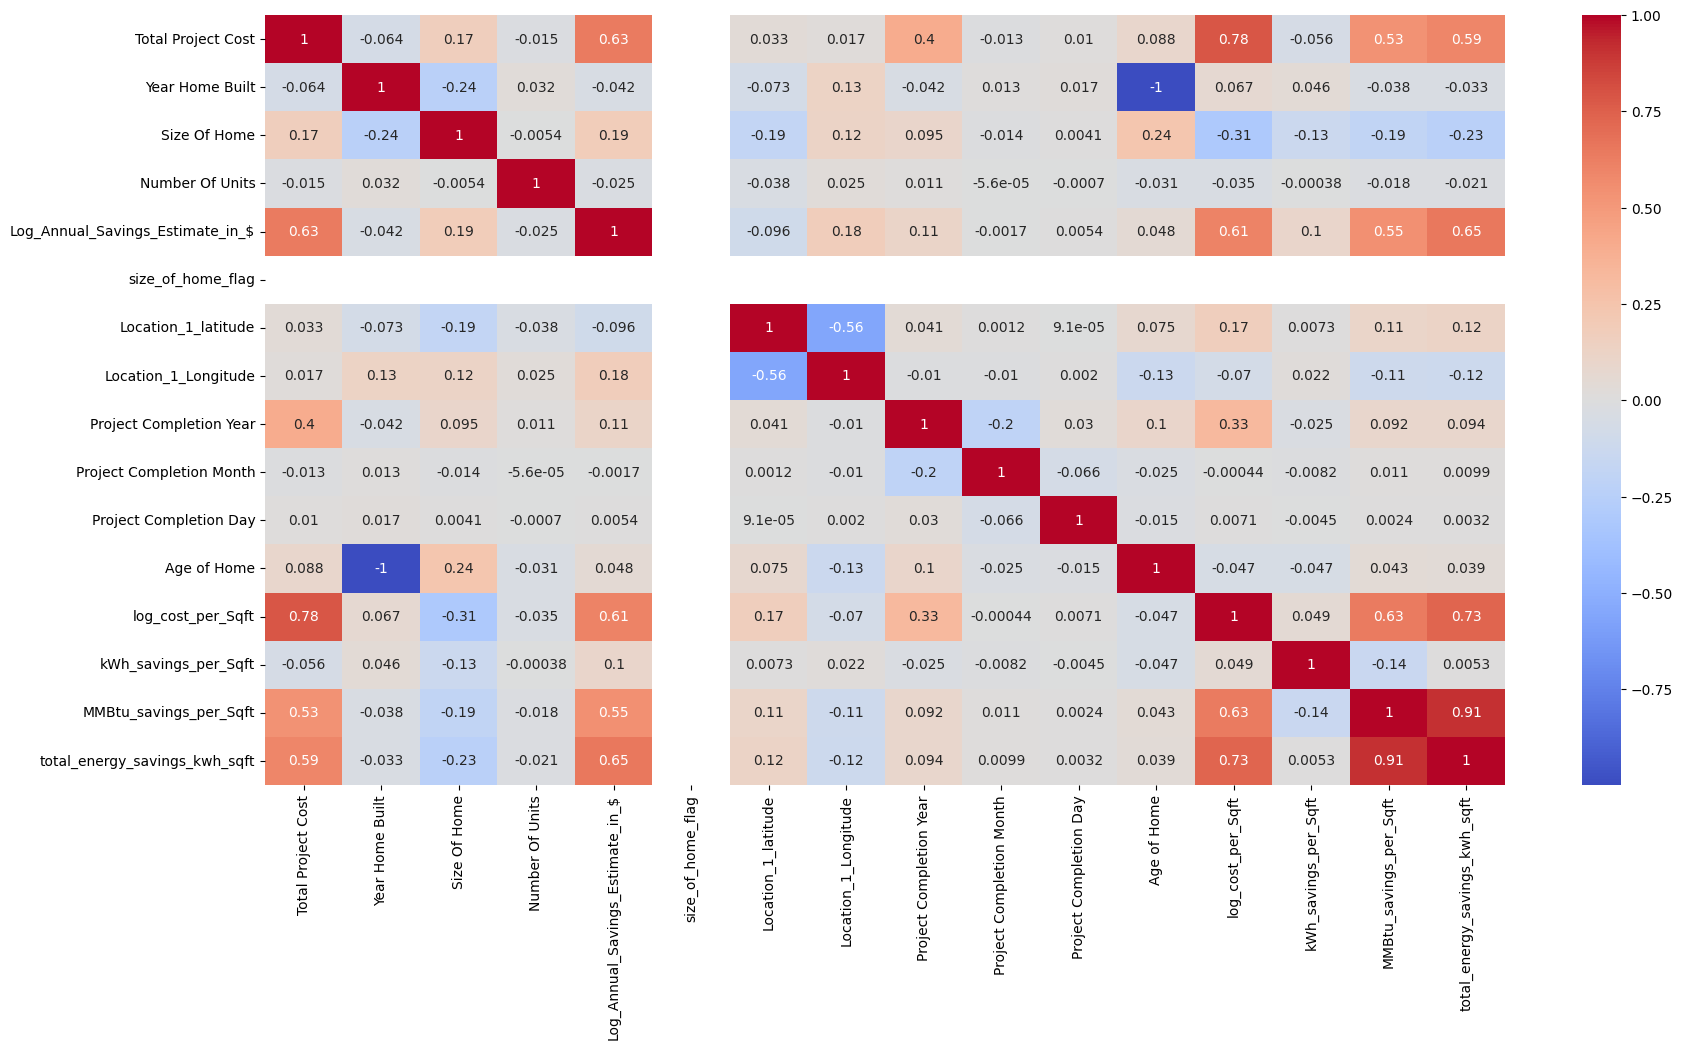

In [ ]:
numric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[numric_cols].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## Findings

1. Delete columns Year Home Built as we have built new derived column Age of Home
2. total_energy_savings_kwh_sqft → 0.65, log_cost_per_Sqft → 0.61, MMBtu_savings_per_Sqft → 0.55, Total Project Cost → 0.63
3. since total energy saving as a strong correlation with MMBtu_savings_per_sqft -> total_energy_savings_kwh_sqft -> 0.91, we can delete either one of the columns, so if we delete MMBtu_savings_per_sqft we need to also delete kWh_savings_per_sqft as the tottal_energy_savings_kwh_sqft contain both these values

*Highly correlated features were removed to avoid multicollinearity. Energy savings variables were consolidated into a single normalized feature (total energy savings per square foot), which showed the strongest relationship with the target. Redundant features such as raw cost and individual energy components were excluded to improve model stability and interpretability.*

# Dropping columns to handle multicolinearity

In [ ]:
data.drop(columns=["Year Home Built","MMBtu_savings_per_Sqft","kWh_savings_per_Sqft"], inplace=True)

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

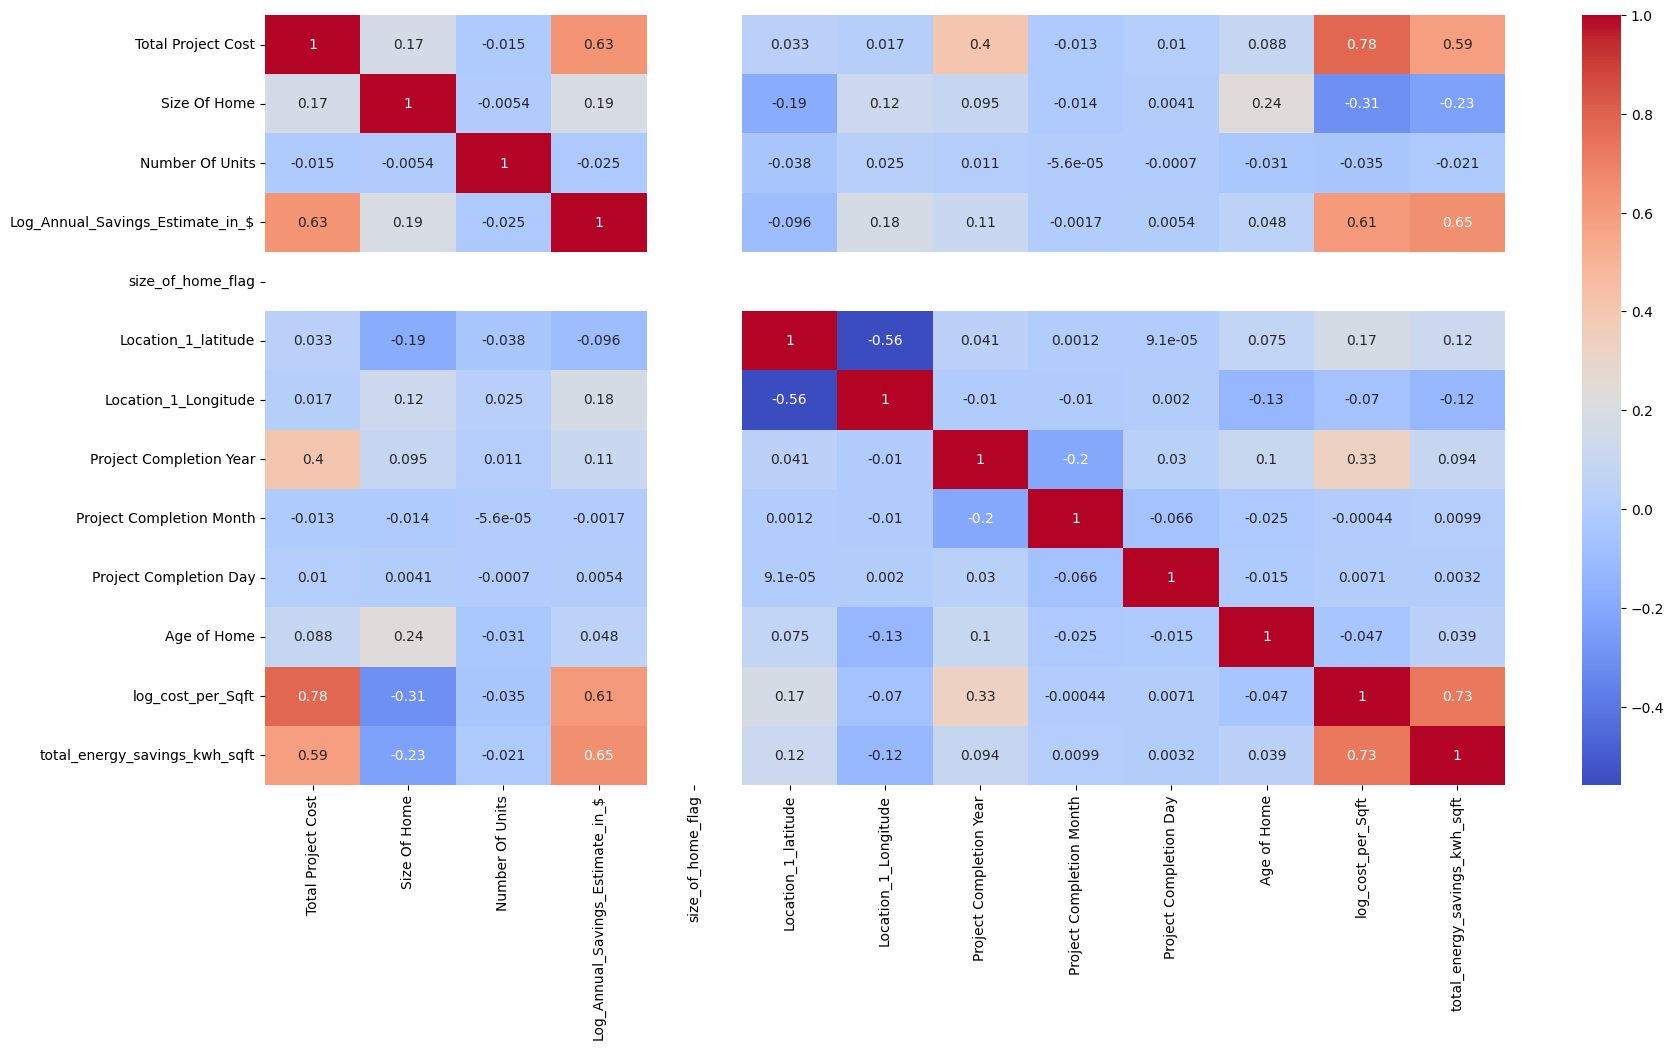

In [ ]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[num_col].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Univariate Analysis

In [ ]:
def hist_plot(column):
    sns.histplot(x=data[column], color='red', bins=50)
    plt.title(f'Histogram of {column}')
    plt.show()

In [ ]:
def pie_plot(column):
    information = data[column].value_counts()
    plt.figure(figsize=(10, 10))
    plt.pie(information, labels=information.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Pie Chart of {column}')
    plt.show()

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

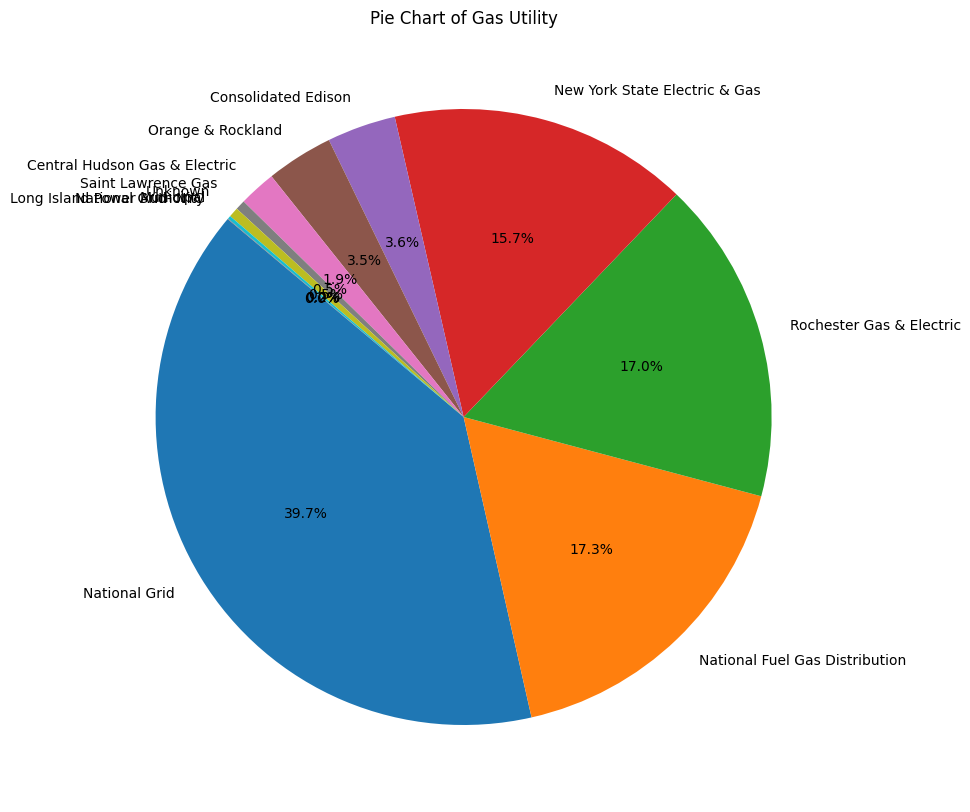

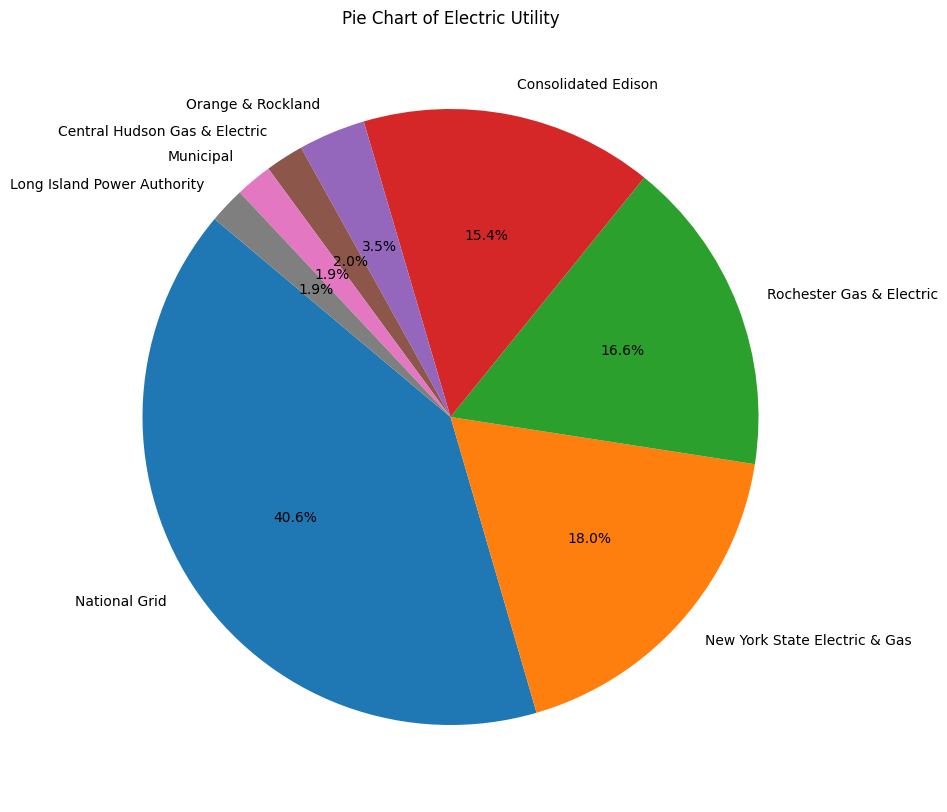

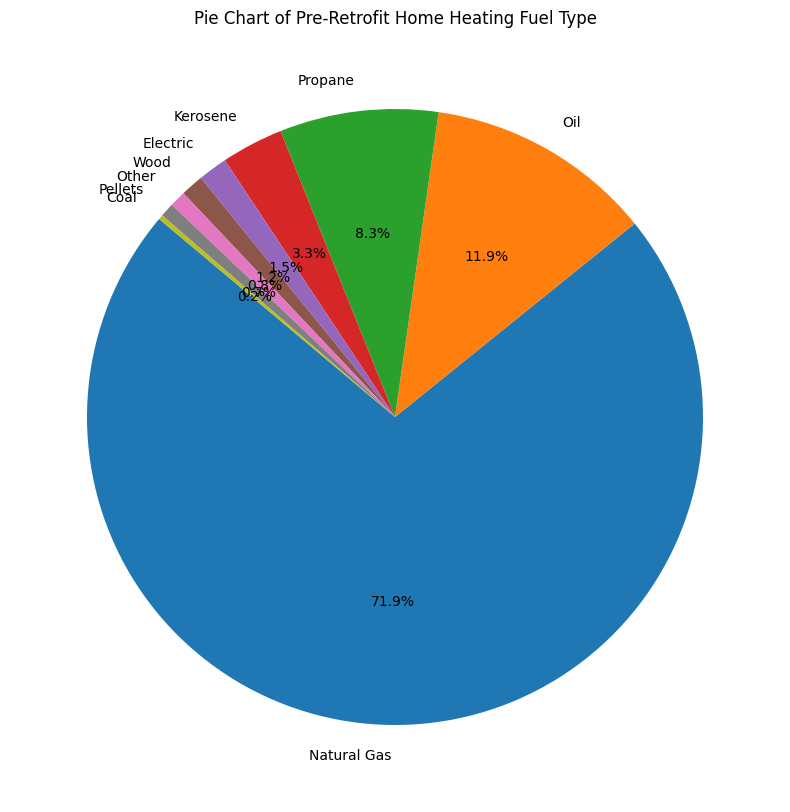

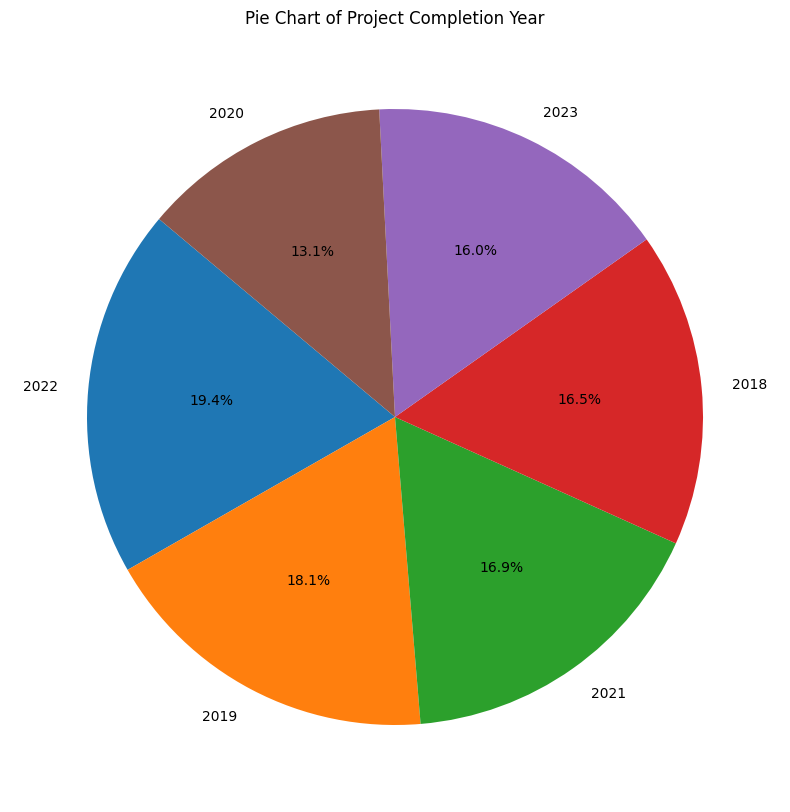

In [ ]:
cat_col = data.select_dtypes(include=['object']).columns
pie_plot('Gas Utility')
pie_plot('Electric Utility')
pie_plot('Pre-Retrofit Home Heating Fuel Type')
pie_plot('Project Completion Year')

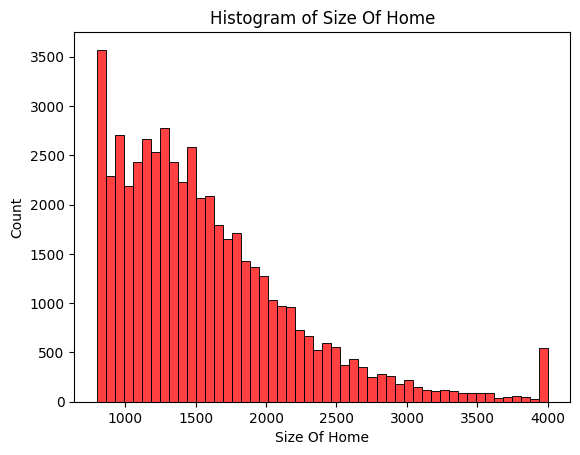

In [ ]:
data['Size Of Home'].value_counts()
hist_plot('Size Of Home')

# Multivaraite

# Target Variable

In [ ]:
data['Log_Annual_Savings_Estimate_in_$'].describe()

,Log_Annual_Savings_Estimate_in_$
count,51867.000000
mean,5.854329
std,0.875218
min,0.000000
25%,5.356586
50%,5.958425
75%,6.444131
max,10.199547


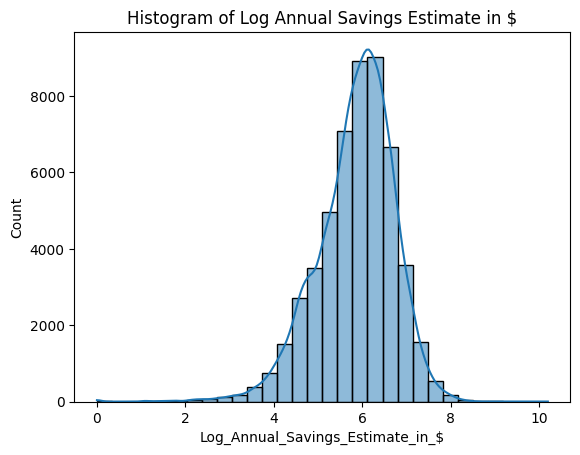

In [ ]:
sns.histplot(data['Log_Annual_Savings_Estimate_in_$'], bins=30, kde=True)
plt.title('Histogram of Log Annual Savings Estimate in $')
plt.show()

# Splitting the data into target variable(y) and independent variable(x)

In [ ]:
y = data['Log_Annual_Savings_Estimate_in_$']
X = data.drop(columns=['Log_Annual_Savings_Estimate_in_$'])

In [ ]:
y

,Log_Annual_Savings_Estimate_in_$
0,6.826545
1,7.221105
2,6.489205
3,6.445720
4,7.490529
...,...
51862,5.638355
51863,5.768321
51864,5.111988
51865,5.713733


In [ ]:
X.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'size_of_home_flag', 'Location_1_latitude',
       'Location_1_Longitude', 'Project Completion Year',
       'Project Completion Month', 'Project Completion Day', 'Age of Home',
       'log_cost_per_Sqft', 'total_energy_savings_kwh_sqft'],
      dtype='object')

In [ ]:
X

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1484,1,Home Performance,Single Family,Building Shell,0,42.110115,-76.032545,2023,6,22,50,2.016250,4.926350
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1664,1,Home Performance,Single Family,Building Shell,0,40.697715,-73.786045,2023,6,22,90,2.095759,12.262431
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1252,1,Home Performance,Single Family,Building Shell,0,43.325035,-76.411740,2023,6,20,79,2.195626,14.092061
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1700,1,Home Performance,Single Family,Building Shell,0,44.695165,-74.704765,2023,6,13,109,1.618806,2.869450
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,2680,1,Home Performance,Single Family,Building Shell,0,43.231255,-75.868192,2023,6,13,132,1.720165,8.787141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51862,Rockland,Pomona,Orange & Rockland,Orange & Rockland,7984.0,Natural Gas,3628,1,Home Performance,Single Family,Building Shell,0,41.190952,-74.034430,2019,7,26,67,1.163358,1.938728
51863,Cayuga,Auburn,New York State Electric & Gas,New York State Electric & Gas,4678.0,Natural Gas,1456,1,Home Performance,Single Family,Building Shell,0,42.935500,-76.566870,2018,11,9,97,1.438154,5.583685
51864,Rensselaer,Troy,National Grid,National Grid,2931.0,Natural Gas,1275,1,Home Performance,Single Family,Building Shell,0,42.726280,-73.688825,2018,11,12,97,1.193566,3.801675
51865,Queens,Queens Village,National Grid,Consolidated Edison,5848.0,Natural Gas,1280,1,Home Performance,Single Family,Building Shell,0,40.723510,-73.737980,2019,5,21,91,1.717171,5.037158


# Encoding of categorical variable

In [ ]:
cat_col

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling',
       'Measure Type'],
      dtype='object')

In [ ]:
cat_col_df = data[cat_col]
cat_col_df.head()

,Project County,Project City,Gas Utility,Electric Utility,Pre-Retrofit Home Heating Fuel Type,Job Type,Type Of Dwelling,Measure Type
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,Oil,Home Performance,Single Family,Building Shell
1,Queens,Queens,National Grid,Consolidated Edison,Natural Gas,Home Performance,Single Family,Building Shell
2,Oswego,Fulton,National Grid,National Grid,Natural Gas,Home Performance,Single Family,Building Shell
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,Oil,Home Performance,Single Family,Building Shell
4,Oswego,Cleveland,National Grid,National Grid,Oil,Home Performance,Single Family,Building Shell


## Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

In [ ]:
cat_col

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling',
       'Measure Type'],
      dtype='object')

In [ ]:
data['Electric Utility'].nunique()

8

In [ ]:
frequency_data = data[['Project County','Project City']]
OHE_data = data[['Job Type','Type Of Dwelling','Measure Type','Pre-Retrofit Home Heating Fuel Type','Gas Utility','Electric Utility']]

### Frequency Encoding

In [ ]:
for i in frequency_data.columns:
    frequency_map = frequency_data[i].value_counts(normalize=True)
    X[i + '_freq'] = data[i].map(frequency_map)

### One Hot Encoding

In [ ]:
le = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = le.fit_transform(X[OHE_data.columns])

# 3. Create a new DataFrame with the new OHE column names
encoded_cols = pd.DataFrame(
    encoded_array,
    columns=le.get_feature_names_out(OHE_data.columns),
    index=X.index
)

# 4. Drop the original text columns and join the new 0/1 columns
X = pd.concat([X.drop(columns=OHE_data.columns), encoded_cols], axis=1)

X.head()

,Project County,Project City,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,Broome,Endicott,9661.0,1484,1,0,42.110115,-76.032545,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Queens,Queens,11867.0,1664,1,0,40.697715,-73.786045,2023,6,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Oswego,Fulton,9998.0,1252,1,0,43.325035,-76.411740,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,St. Lawrence,Nicholville,6880.0,1700,1,0,44.695165,-74.704765,2023,6,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Oswego,Cleveland,12289.0,2680,1,0,43.231255,-75.868192,2023,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X = X.drop(columns=['Project County', 'Project City'])

In [ ]:
X.head()

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,9661.0,1484,1,0,42.110115,-76.032545,2023,6,22,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,11867.0,1664,1,0,40.697715,-73.786045,2023,6,22,90,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,9998.0,1252,1,0,43.325035,-76.411740,2023,6,20,79,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,6880.0,1700,1,0,44.695165,-74.704765,2023,6,13,109,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,12289.0,2680,1,0,43.231255,-75.868192,2023,6,13,132,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
X.isnull().sum()

,0
Total Project Cost,0
Size Of Home,0
Number Of Units,0
size_of_home_flag,0
Location_1_latitude,0
Location_1_Longitude,0
Project Completion Year,0
Project Completion Month,0
Project Completion Day,0
Age of Home,0


# Standard Scalar

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
0,0.776243,-0.141343,-0.026711,0.0,-0.390346,0.045745,1.439575,-0.0129,0.715990,-0.761603,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
1,1.307180,0.145439,-0.026711,0.0,-1.845611,1.270396,1.439575,-0.0129,0.715990,0.595777,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
2,0.857352,-0.510972,-0.026711,0.0,0.861446,-0.160968,1.439575,-0.0129,0.484818,0.222498,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
3,0.106916,0.202795,-0.026711,0.0,2.273158,0.769567,1.439575,-0.0129,-0.324287,1.240533,...,13.927983,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
4,1.408747,1.764162,-0.026711,0.0,0.764819,0.135340,1.439575,-0.0129,-0.324287,2.021027,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422


# Split the data into train and test split

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
x_train

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
2290,1.199356,0.285643,-0.026711,0.0,0.624718,0.484583,1.439575,-0.012900,-1.711323,0.324301,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
31067,-0.420651,1.636704,-0.026711,0.0,-1.883734,1.199953,-0.306859,0.866693,0.947163,0.527908,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
10490,0.671307,1.636704,-0.026711,0.0,0.470114,1.049002,1.439575,-0.306097,0.022472,0.561843,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
48414,-0.096217,-1.151452,-0.026711,0.0,-0.438909,0.375481,-1.471148,0.573495,0.831577,-0.490127,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
10171,1.193339,-0.096732,-0.026711,0.0,0.586505,-0.818520,0.857431,-0.892492,1.525095,-0.082913,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.090200,-1.052671,-0.026711,0.0,0.557106,-1.503145,1.439575,-0.892492,-0.786632,0.460039,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
44732,1.220777,-0.737211,-0.026711,0.0,-0.344949,-1.627014,-1.471148,1.159890,-0.555459,0.052825,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
38158,-1.392512,-0.052122,-0.026711,0.0,0.504390,-0.679430,-0.889003,-0.306097,0.831577,0.460039,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
860,1.774578,-0.185953,-0.026711,0.0,-0.424600,1.181503,1.439575,-1.478888,1.062749,0.426105,...,-0.071798,-0.071798,6.984010,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422


In [ ]:
y_train

,Log_Annual_Savings_Estimate_in_$
2290,6.643790
31067,6.126869
10490,6.167516
48414,6.712956
10171,6.291569
...,...
11284,5.298317
44732,7.178545
38158,3.433987
860,6.476972


In [ ]:
x_test

,Total Project Cost,Size Of Home,Number Of Units,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,...,Gas Utility_Saint Lawrence Gas,Gas Utility_Unknown,Electric Utility_Central Hudson Gas & Electric,Electric Utility_Consolidated Edison,Electric Utility_Long Island Power Authority,Electric Utility_Municipal,Electric Utility_National Grid,Electric Utility_New York State Electric & Gas,Electric Utility_Orange & Rockland,Electric Utility_Rochester Gas & Electric
25886,-1.416580,0.601103,-0.026711,0.0,0.135696,-1.621794,-0.306859,-1.478888,-0.208700,2.156765,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
16112,1.618618,-0.976196,-0.026711,0.0,0.581090,0.967090,1.439575,-0.306097,-1.595736,-0.252586,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,1.209133,-0.469254,-0.19097,-0.446422
11667,0.323286,1.904366,0.432641,0.0,-1.871504,1.189227,0.857431,1.746285,0.715990,-0.116848,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
42784,-0.965066,-0.232157,-0.026711,0.0,-0.104878,-1.813339,-1.471148,-0.599295,-0.671046,-0.184717,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,7.143043,-0.827039,-0.469254,-0.19097,-0.446422
25850,0.349520,2.281962,-0.026711,0.0,-1.882332,1.298277,-0.889003,0.866693,-1.480150,0.154629,...,-0.071798,-0.071798,-0.143184,2.345996,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,-0.446422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17532,-1.420671,-0.969823,-0.026711,0.0,0.425088,-1.404571,0.857431,-1.185690,-0.671046,-0.184717,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
42235,-0.765303,-1.219961,-0.026711,0.0,0.714003,-0.814054,-1.471148,-1.478888,0.831577,0.222498,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,-0.469254,-0.19097,2.240034
13312,0.456381,0.433814,-0.026711,0.0,-0.399423,0.113469,0.857431,-1.478888,0.253645,0.188563,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422
24633,1.092736,-0.087173,-0.026711,0.0,0.056192,-0.999847,-0.889003,1.159890,0.138059,1.036926,...,-0.071798,-0.071798,-0.143184,-0.426258,-0.138919,-0.139996,-0.827039,2.131043,-0.19097,-0.446422


In [ ]:
y_test

,Log_Annual_Savings_Estimate_in_$
25886,1.609438
16112,6.536692
11667,6.966967
42784,5.030438
25850,6.642487
...,...
17532,3.988984
42235,5.384495
13312,5.820083
24633,5.872118


# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

linearmodel = LinearRegression()
linearmodel.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = linearmodel.predict(x_test)
lr_y_pred = y_pred
y_pred

array([4.34902369, 6.52642557, 6.54443216, ..., 5.63673882, 6.00901558,
       4.87630464])

## accuracy Measure

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
lr_mse = mse
lr_r2 = r2
lr_mae = mae

Mean Squared Error: 0.202314411839332
R-squared: 0.7385113664650689
Mean Absolute Error: 0.29139444703050943


# OLS Linear Regression

In [ ]:
# Merge X and y into one DataFrame (smf needs it)
train_df = x_train.copy()
train_df['target'] = y_train.values

test_df = x_test.copy()
test_df['target'] = y_test.values

formula = (
    'target ~ '
    'log_cost_per_Sqft + '
    'total_energy_savings_kwh_sqft + '
    'Q("Total Project Cost") + '
    'Q("Size Of Home") + '
    'Q("Age of Home") + '
    'Q("Project Completion Year") + '
    'Q("Job Type_Home Performance") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Oil") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Propane") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Kerosene") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Electric") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Wood") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Pellets") + '
    'Q("Electric Utility_Consolidated Edison") + '
    'Q("Electric Utility_Rochester Gas & Electric") + '
    'Q("Electric Utility_New York State Electric & Gas") + '
    'Q("Project County_freq")'
)

model = smf.ols(formula, data=train_df).fit()
ols_model = model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     7139.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:20:45   Log-Likelihood:                -24918.
No. Observations:               41493   AIC:                         4.987e+04
Df Residuals:                   41475   BIC:                         5.003e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

## OLS Accuracy measure

In [ ]:
y_pred = model.predict(test_df)
ols_y_pred = y_pred
ols_y_pred

,0
25886,4.423211
16112,6.495959
11667,6.588141
42784,5.043329
25850,6.816362
...,...
17532,3.798476
42235,5.320591
13312,5.590317
24633,6.043164


In [ ]:
y_test = test_df['target']
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
ols_mse = mse
ols_r2 = r2
ols_mae = mae

Mean Squared Error: 0.2068306672555074
R-squared: 0.7326741675886572
Mean Absolute Error: 0.29586105166755716


## AIC Evaluation for OLS

In [ ]:
import itertools

# Base features (always included — strongest predictors)
base = [
    'log_cost_per_Sqft',
    'total_energy_savings_kwh_sqft',
    'Q("Total Project Cost")',
    'Q("Job Type_Home Performance")',
]

# Candidate features to test adding/removing
candidates = [
    'Q("Size Of Home")',
    'Q("Age of Home")',
    'Q("Project Completion Year")',
    'Q("Project County_freq")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Oil")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Propane")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Kerosene")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Electric")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Wood")',
    'Q("Pre-Retrofit Home Heating Fuel Type_Pellets")',
    'Q("Electric Utility_Consolidated Edison")',
    'Q("Electric Utility_Rochester Gas & Electric")',
    'Q("Electric Utility_New York State Electric & Gas")',
]

# add one feature at a time, keep if AIC improves
print('FORWARD STEPWISE FEATURE SELECTION (by AIC)')

current_features = base.copy()
remaining = candidates.copy()
best_aic = smf.ols('target ~ ' + ' + '.join(current_features), data=train_df).fit().aic
print(f'\nBase model AIC: {best_aic:.2f}  ({len(current_features)} features)')

step = 0
while remaining:
    step += 1
    results = []

    for feat in remaining:
        trial = current_features + [feat]
        formula_trial = 'target ~ ' + ' + '.join(trial)
        m = smf.ols(formula_trial, data=train_df).fit()
        results.append((feat, m.aic, m.bic, m.rsquared_adj))

    results.sort(key=lambda x: x[1])  # sort by AIC
    best_feat, best_new_aic, best_bic, best_adj_r2 = results[0]

    if best_new_aic < best_aic:
        current_features.append(best_feat)
        remaining.remove(best_feat)
        improvement = best_aic - best_new_aic
        best_aic = best_new_aic
        print(f'  Step {step}: + {best_feat:55s} AIC={best_aic:.2f} (Δ={-improvement:.2f})  Adj R²={best_adj_r2:.4f}')
    else:
        print(f'\n  Step {step}: No improvement. Stopping.')
        break

# Final selected formula
final_formula = 'target ~ ' + ' + '.join(current_features)
print(f'\n SELECTED FEATURES ({len(current_features)}):')
for f in current_features:
    print(f)

# Fit final model
final_model = smf.ols(final_formula, data=train_df).fit()

# Compare: base vs final
base_model = smf.ols('target ~ ' + ' + '.join(base), data=train_df).fit()
y_pred_base = base_model.predict(test_df)
y_pred_final = final_model.predict(test_df)

r2=r2_score(test_df['target'], y_pred_final)
rmse=np.sqrt(mean_squared_error(test_df['target'], y_pred_final))
mae = mean_absolute_error(test_df['target'], y_pred_final)
aic =  final_model.aic
bic = final_model.bic
mse = mean_squared_error(test_df['target'], y_pred_final)
adj_r2 = final_model.rsquared_adj
features = current_features
print(f'\n BASE MODEL vs TUNED MODEL (Test Set)')
print(f'  {"Metric":<20s} {"Base (4 features)":>20s} {"Tuned":>20s}')
print(f'  {"R²":<20s} {r2_score(test_df["target"], y_pred_base):>20.4f} {r2_score(test_df["target"], y_pred_final):>20.4f}')
print(f'  {"RMSE":<20s} {np.sqrt(mean_squared_error(test_df["target"], y_pred_base)):>20.4f} {np.sqrt(mean_squared_error(test_df["target"], y_pred_final)):>20.4f}')
print(f'  {"MAE":<20s} {mean_absolute_error(test_df["target"], y_pred_base):>20.4f} {mean_absolute_error(test_df["target"], y_pred_final):>20.4f}')
print(f'  {"AIC":<20s} {base_model.aic:>20.2f} {final_model.aic:>20.2f}')
print(f'  {"BIC":<20s} {base_model.bic:>20.2f} {final_model.bic:>20.2f}')
print(f'  {"Adj R²":<20s} {base_model.rsquared_adj:>20.4f} {final_model.rsquared_adj:>20.4f}')
print(f'  {"# Features":<20s} {len(base):>20d} {len(current_features):>20d}')

aic_r2 = r2
aic_rmse = rmse
aic_mse = mse
aic_mae = mae
aic_features = features
aic_model = final_model
aic_y_pred = y_pred_final

FORWARD STEPWISE FEATURE SELECTION (by AIC)

Base model AIC: 75502.46  (4 features)
  Step 1: + Q("Size Of Home")                                       AIC=65937.54 (Δ=-9564.92)  Adj R²=0.6246
  Step 2: + Q("Project County_freq")                                AIC=62525.03 (Δ=-3412.51)  Adj R²=0.6543
  Step 3: + Q("Electric Utility_Consolidated Edison")               AIC=60016.23 (Δ=-2508.80)  Adj R²=0.6745
  Step 4: + Q("Pre-Retrofit Home Heating Fuel Type_Oil")            AIC=57319.54 (Δ=-2696.69)  Adj R²=0.6950
  Step 5: + Q("Pre-Retrofit Home Heating Fuel Type_Propane")        AIC=53074.82 (Δ=-4244.72)  Adj R²=0.7247
  Step 6: + Q("Pre-Retrofit Home Heating Fuel Type_Kerosene")       AIC=51283.78 (Δ=-1791.04)  Adj R²=0.7363
  Step 7: + Q("Project Completion Year")                            AIC=50394.58 (Δ=-889.19)  Adj R²=0.7419
  Step 8: + Q("Pre-Retrofit Home Heating Fuel Type_Pellets")        AIC=50242.85 (Δ=-151.73)  Adj R²=0.7429
  Step 9: + Q("Pre-Retrofit Home Heating Fuel 

## Polynomial Model for OLS

In [ ]:
# ── Polynomial & Interaction Features ──
train_df['log_cost_sq'] = train_df['log_cost_per_Sqft'] ** 2
train_df['energy_sq'] = train_df['total_energy_savings_kwh_sqft'] ** 2
train_df['energy_cu'] = train_df['total_energy_savings_kwh_sqft'] ** 3
train_df['cost_raw_sq'] = train_df['Total Project Cost'] ** 2
train_df['cost_raw_cu'] = train_df['Total Project Cost'] ** 3
train_df['size_sq'] = train_df['Size Of Home'] ** 2
train_df['size_cu'] = train_df['Size Of Home'] ** 3
train_df['year_sq'] = train_df['Project Completion Year'] ** 2
train_df['cost_x_energy'] = train_df['log_cost_per_Sqft'] * train_df['total_energy_savings_kwh_sqft']
train_df['cost_x_size'] = train_df['log_cost_per_Sqft'] * train_df['Size Of Home']
train_df['energy_x_size'] = train_df['total_energy_savings_kwh_sqft'] * train_df['Size Of Home']
train_df['costraw_x_size'] = train_df['Total Project Cost'] * train_df['Size Of Home']

# Same for test_df
test_df['log_cost_sq'] = test_df['log_cost_per_Sqft'] ** 2
test_df['energy_sq'] = test_df['total_energy_savings_kwh_sqft'] ** 2
test_df['energy_cu'] = test_df['total_energy_savings_kwh_sqft'] ** 3
test_df['cost_raw_sq'] = test_df['Total Project Cost'] ** 2
test_df['cost_raw_cu'] = test_df['Total Project Cost'] ** 3
test_df['size_sq'] = test_df['Size Of Home'] ** 2
test_df['size_cu'] = test_df['Size Of Home'] ** 3
test_df['year_sq'] = test_df['Project Completion Year'] ** 2
test_df['cost_x_energy'] = test_df['log_cost_per_Sqft'] * test_df['total_energy_savings_kwh_sqft']
test_df['cost_x_size'] = test_df['log_cost_per_Sqft'] * test_df['Size Of Home']
test_df['energy_x_size'] = test_df['total_energy_savings_kwh_sqft'] * test_df['Size Of Home']
test_df['costraw_x_size'] = test_df['Total Project Cost'] * test_df['Size Of Home']

# ── OLS Formula ──
formula = (
    'target ~ '
    'log_cost_per_Sqft + log_cost_sq + '
    'total_energy_savings_kwh_sqft + energy_sq + energy_cu + '
    'Q("Total Project Cost") + cost_raw_sq + cost_raw_cu + '
    'Q("Size Of Home") + size_sq + size_cu + '
    'Q("Project Completion Year") + year_sq + '
    'Q("Age of Home") + '
    'cost_x_energy + cost_x_size + energy_x_size + costraw_x_size + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Oil") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Propane") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Kerosene") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Electric") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Wood") + '
    'Q("Pre-Retrofit Home Heating Fuel Type_Pellets") + '
    'Q("Electric Utility_Consolidated Edison") + '
    'Q("Electric Utility_New York State Electric & Gas") + '
    'Q("Project County_freq")'
)

model = smf.ols(formula, data=train_df).fit()
poly_model = model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     7434.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:20:51   Log-Likelihood:                -16679.
No. Observations:               41493   AIC:                         3.341e+04
Df Residuals:                   41465   BIC:                         3.366e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [ ]:
y_pred = model.predict(test_df)
poly_y_pred = y_pred
poly_y_pred

,0
25886,3.949656
16112,6.257267
11667,6.822553
42784,5.258116
25850,6.875788
...,...
17532,3.742278
42235,5.406396
13312,5.660926
24633,6.045102


In [ ]:
y_test = test_df['target']
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
poly_mse = mse
poly_r2 = r2
poly_mae = mae

Mean Squared Error: 0.14039825565391478
R-squared: 0.8185371586341295
Mean Absolute Error: 0.21590785126623047


Final formula for OLS with polynomial model:

ŷ = β₀ + β₁·logCost + β₂·logCost² + β₃·energy + β₄·energy² + β₅·energy³ + β₆·cost + β₇·cost² + β₈·cost³ + β₉·size + β₁₀·size² + β₁₁·size³ + β₁₂·year + β₁₃·year² + β₁₄·age + β₁₅·(logCost × energy) + β₁₆·(logCost × size) + β₁₇·(energy × size) + β₁₈·(cost × size) + Σ γₖ·𝟙ₖ

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_y_pred = rf_model.predict(x_test)
rf_y_pred

array([3.31071159, 6.24069713, 6.86016538, ..., 5.66409436, 5.86776562,
       4.59395338])

In [ ]:
mse = mean_squared_error(y_test, rf_y_pred)
r2 = r2_score(y_test, rf_y_pred)
mae = mean_absolute_error(y_test, rf_y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
rf_mse = mse
rf_r2 = r2
rf_mae = mae

Mean Squared Error: 0.11730291728892182
R-squared: 0.848387570254261
Mean Absolute Error: 0.1899638921926941


# Hyperparameter Tuning

In [ ]:
n_estimators = [50, 100, 200]
max_depth = [None, 10, 20, 30]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions={
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}, n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(x_train, y_train)

In [ ]:
print(f'Best Parameters: {rf_random.best_params_}')

In [ ]:
hypercv_rf_model = RandomForestRegressor(n_estimators= 200, min_samples_split= 5, min_samples_leaf= 4, max_depth= 20, random_state=42)
hypercv_rf_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=4, min_samples_split=5,
                      n_estimators=200, random_state=42)

In [ ]:
hypercv_ypred = hypercv_rf_model.predict(x_test)
hypercv_ypred

array([3.19985503, 6.2768084 , 6.86600788, ..., 5.66761533, 5.86300985,
       4.57940592])

In [ ]:
hypermse = mean_squared_error(y_test, hypercv_ypred)
print(f'Mean Squared Error: {hypermse}')
hypermae = mean_absolute_error(y_test, hypercv_ypred)
print(f'Mean Absolute Error: {hypermae}')
hyperr22 = r2_score(y_test, hypercv_ypred)
print(f'R-squared: {hyperr22}')

Mean Squared Error: 0.11419874595943597
Mean Absolute Error: 0.18770407744351236
R-squared: 0.8523996695991667


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train, y_train)

#Feed-Forward Neural Network

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else
                       'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(x_train.values).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(x_test.values).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

input_dim = x_train.shape[1]
print(f'Input features: {input_dim}')
print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Input features: 51
Training samples: 41493
Test samples: 10374



## Model Architecture

In [ ]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.2):
        super(FeedForwardNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print('Model class defined.')


Model class defined.


# Training

In [ ]:
def train_model(model, train_loader, X_test_tensor, y_test_tensor,
                epochs=100, lr=0.001, patience=10):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)

        train_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test_tensor)
            val_loss = criterion(val_pred, y_test_tensor).item()
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # Restore best model
    model.load_state_dict(best_model_state)
    return train_losses, val_losses

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

architectures = {
    '1-Layer (64)':          [64],
    '2-Layer (128-64)':      [128, 64],
    '3-Layer (128-64-32)':   [128, 64, 32],
    '4-Layer (256-128-64-32)': [256, 128, 64, 32]
}

results = {}

for name, hidden_dims in architectures.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')

    model = FeedForwardNN(input_dim, hidden_dims, dropout_rate=0.2).to(device)

    # Print parameter count
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {n_params:,}')

    train_losses, val_losses = train_model(
        model, train_loader, X_test_tensor, y_test_tensor,
        epochs=150, lr=0.001, patience=15
    )

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).cpu().numpy().flatten()

    y_true = y_test.values
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f'\nResults:')
    print(f'  R-squared: {r2:.4f}')
    print(f'  RMSE:      {rmse:.4f}')
    print(f'  MAE:       {mae:.4f}')

    results[name] = {
        'model': model,
        'r2': r2, 'rmse': rmse, 'mae': mae,
        'train_losses': train_losses, 'val_losses': val_losses,
        'y_pred': y_pred, 'n_params': n_params
    }


Training: 1-Layer (64)
Parameters: 3,521
Epoch  10 | Train Loss: 0.5014 | Val Loss: 0.2095
Epoch  20 | Train Loss: 0.4125 | Val Loss: 0.2049
Epoch  30 | Train Loss: 0.3674 | Val Loss: 0.2013
Epoch  40 | Train Loss: 0.3323 | Val Loss: 0.2001
Epoch  50 | Train Loss: 0.3069 | Val Loss: 0.1954
Epoch  60 | Train Loss: 0.2943 | Val Loss: 0.1935
Epoch  70 | Train Loss: 0.2890 | Val Loss: 0.1944
Epoch  80 | Train Loss: 0.2820 | Val Loss: 0.1944
Early stopping at epoch 90

Results:
  R-squared: 0.7487
  RMSE:      0.4410
  MAE:       0.2878

Training: 2-Layer (128-64)
Parameters: 15,361
Epoch  10 | Train Loss: 0.4352 | Val Loss: 0.1563
Epoch  20 | Train Loss: 0.3382 | Val Loss: 0.1394
Epoch  30 | Train Loss: 0.2962 | Val Loss: 0.1328
Epoch  40 | Train Loss: 0.2640 | Val Loss: 0.1294
Epoch  50 | Train Loss: 0.2426 | Val Loss: 0.1246
Epoch  60 | Train Loss: 0.2290 | Val Loss: 0.1227
Epoch  70 | Train Loss: 0.2224 | Val Loss: 0.1224
Epoch  80 | Train Loss: 0.2204 | Val Loss: 0.1238
Epoch  90 | Tr

In [ ]:
comparison_df = pd.DataFrame({
    name: {'R²': r['r2'], 'RMSE': r['rmse'], 'MAE': r['mae'], 'Parameters': r['n_params']}
    for name, r in results.items()
}).T
comparison_df

,R²,RMSE,MAE,Parameters
1-Layer (64),0.748684,0.440958,0.287799,3521.0
2-Layer (128-64),0.844580,0.346769,0.185969,15361.0
3-Layer (128-64-32),0.844471,0.346891,0.191787,17473.0
4-Layer (256-128-64-32),0.844712,0.346622,0.189884,57537.0


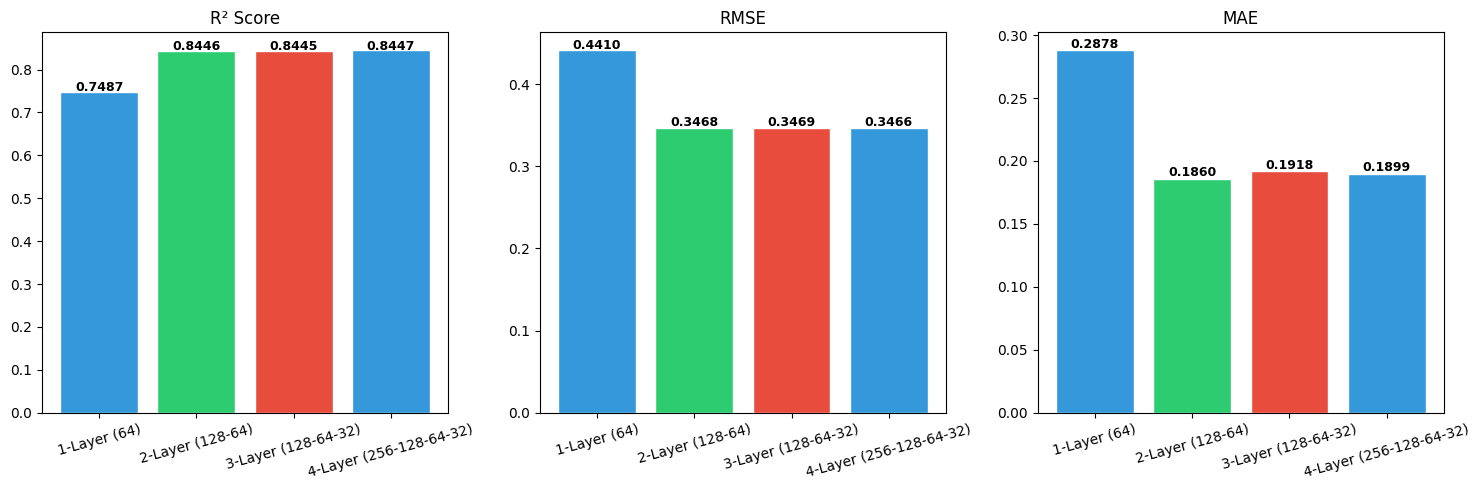

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, title in zip(axes, ['r2', 'rmse', 'mae'], ['R² Score', 'RMSE', 'MAE']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Best NN

In [ ]:
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
best_model = best['model']
y_pred = best['y_pred']

print(f'Best architecture: {best_name}')
print(f'R²:   {best["r2"]:.4f}')
print(f'RMSE: {best["rmse"]:.4f}')
print(f'MAE:  {best["mae"]:.4f}')
ffnn_model = best_model
ffnn_y_pred = y_pred

Best architecture: 4-Layer (256-128-64-32)
R²:   0.8447
RMSE: 0.3466
MAE:  0.1899


## Training and Validation Loss

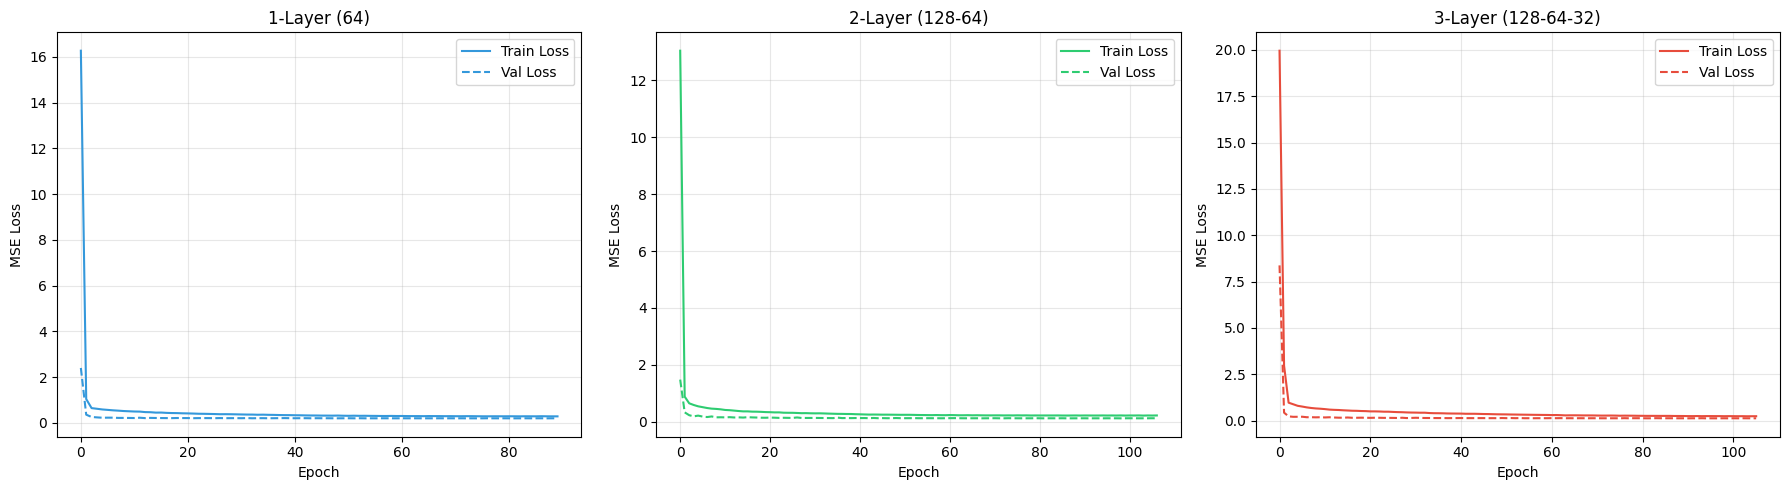

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r), color in zip(axes, results.items(), colors):
    ax.plot(r['train_losses'], label='Train Loss', color=color, linewidth=1.5)
    ax.plot(r['val_losses'], label='Val Loss', color=color, linewidth=1.5, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Best model Accuracy Measure

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')
ffnn_mse = mse
ffnn_r2 = r2
ffnn_mae = mae
ffnn_rmse = rmse

Mean Squared Error: 0.12014694052679886
Root Mean Squared Error: 0.346622187008851
R-squared: 0.8447117087896578
Mean Absolute Error: 0.18988402302695156


Residual Analysis

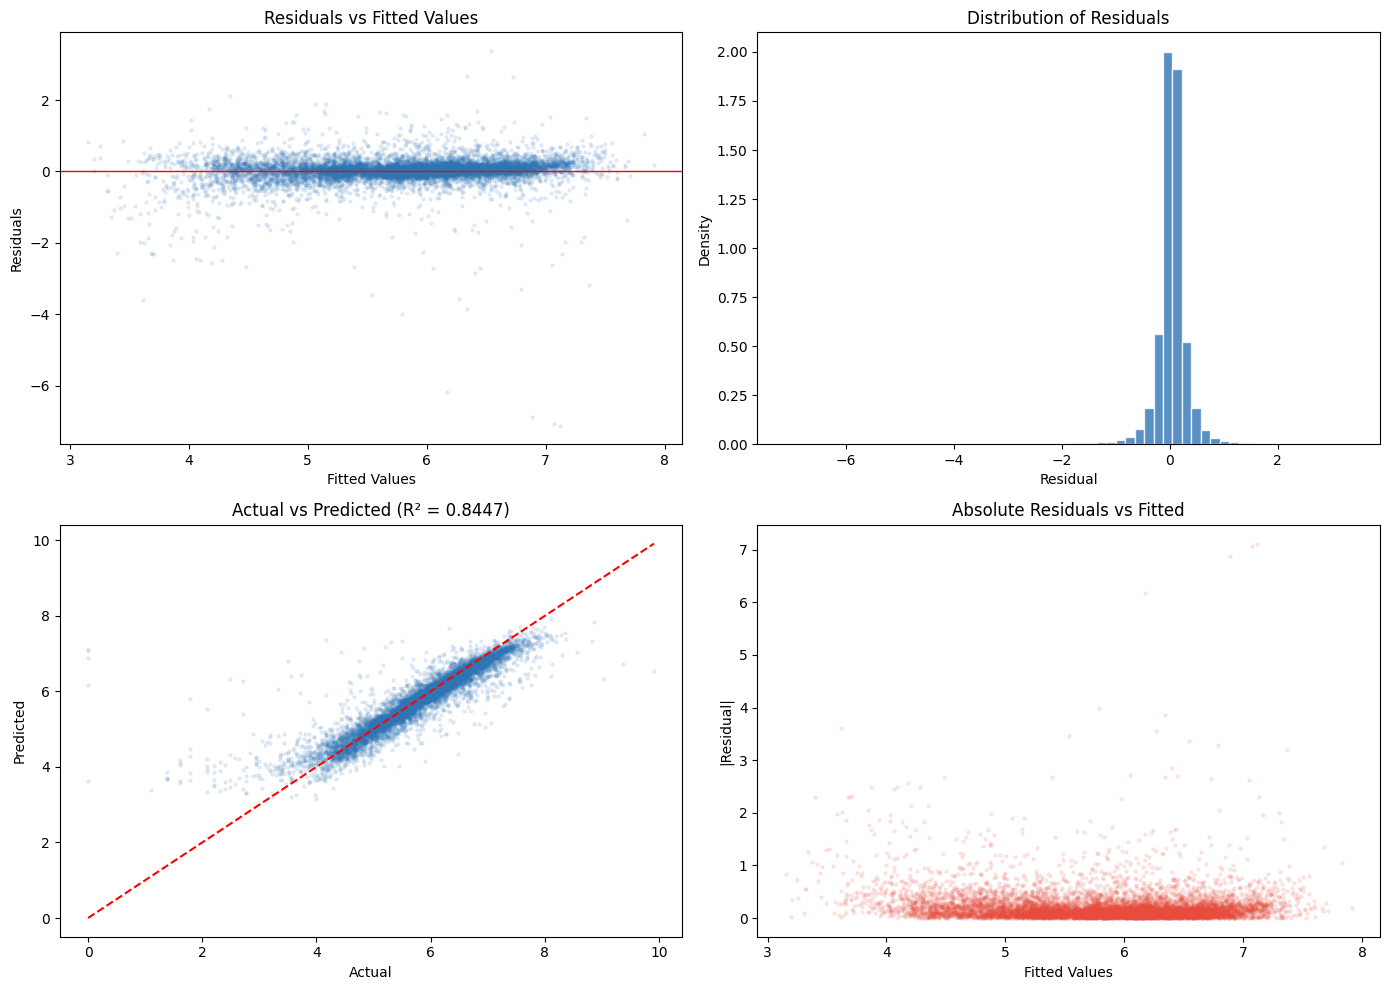

In [ ]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.1, s=5, color='#2E75B6')
axes[0, 0].axhline(y=0, color='red', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=60, color='#2E75B6', edgecolor='white', alpha=0.8, density=True)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Distribution of Residuals')

# 3. Actual vs Predicted
axes[1, 0].scatter(y_test, y_pred, alpha=0.1, s=5, color='#2E75B6')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')

# 4. Residual distribution by prediction range
axes[1, 1].scatter(y_pred, np.abs(residuals), alpha=0.1, s=5, color='#e74c3c')
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('|Residual|')
axes[1, 1].set_title('Absolute Residuals vs Fitted')

plt.tight_layout()
plt.show()

## Feature Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Wrap PyTorch model for sklearn compatibility
class PyTorchWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y):
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
            return self.model(X_tensor).cpu().numpy().flatten()

wrapper = PyTorchWrapper(best_model, device)

perm_result = permutation_importance(
    wrapper, x_test, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

perm_df

,Feature,Importance Mean,Importance Std
11,total_energy_savings_kwh_sqft,9.843684e-01,0.011134
1,Size Of Home,2.173200e-01,0.002522
38,Gas Utility_New York State Electric & Gas,9.898312e-02,0.004846
10,log_cost_per_Sqft,6.498958e-02,0.001455
25,Pre-Retrofit Home Heating Fuel Type_Natural Gas,6.182774e-02,0.001264
40,Gas Utility_Rochester Gas & Electric,4.298566e-02,0.002528
0,Total Project Cost,3.859040e-02,0.001601
29,Pre-Retrofit Home Heating Fuel Type_Propane,3.036608e-02,0.001631
44,Electric Utility_Consolidated Edison,3.032022e-02,0.001234
26,Pre-Retrofit Home Heating Fuel Type_Oil,1.969720e-02,0.000517


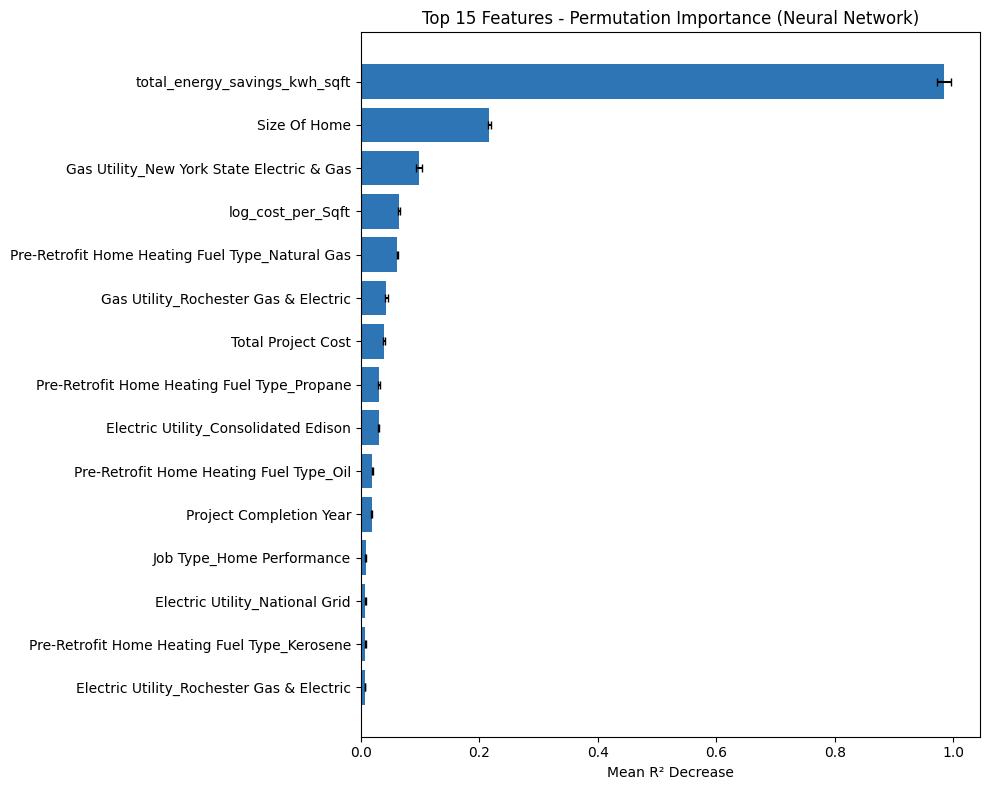

In [ ]:
# Feature importance plot
top_features = perm_df.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance Mean'][::-1],
         xerr=top_features['Importance Std'][::-1], color='#2E75B6', capsize=3)
plt.xlabel('Mean R² Decrease')
plt.title('Top 15 Features - Permutation Importance (Neural Network)')
plt.tight_layout()
plt.show()

## Hyper-Parameter Tuning

In [ ]:
# Get hidden dims of best architecture
best_hidden = architectures[best_name]
print(f'Tuning architecture: {best_name} = {best_hidden}')

tuning_configs = [
    {'lr': 0.001,  'dropout': 0.1},
    {'lr': 0.001,  'dropout': 0.2},
    {'lr': 0.001,  'dropout': 0.3},
    {'lr': 0.0005, 'dropout': 0.2},
    {'lr': 0.002,  'dropout': 0.2},
]

tuning_results = []

for config in tuning_configs:
    label = f"lr={config['lr']}, dropout={config['dropout']}"
    print(f'\nTraining: {label}')

    model = FeedForwardNN(input_dim, best_hidden, dropout_rate=config['dropout']).to(device)
    train_losses, val_losses = train_model(
        model, train_loader, X_test_tensor, y_test_tensor,
        epochs=150, lr=config['lr'], patience=15
    )

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).cpu().numpy().flatten()

    r2_val = r2_score(y_test, preds)
    rmse_val = np.sqrt(mean_squared_error(y_test, preds))

    print(f'  R²: {r2_val:.4f} | RMSE: {rmse_val:.4f}')
    tuning_results.append({
        'Config': label, 'R²': r2_val, 'RMSE': rmse_val,
        'model': model, 'y_pred': preds
    })

tuning_df = pd.DataFrame(tuning_results)[['Config', 'R²', 'RMSE']]
tuning_df

Tuning architecture: 4-Layer (256-128-64-32) = [256, 128, 64, 32]

Training: lr=0.001, dropout=0.1
Epoch  10 | Train Loss: 0.3733 | Val Loss: 0.1507
Epoch  20 | Train Loss: 0.2960 | Val Loss: 0.1300
Epoch  30 | Train Loss: 0.2599 | Val Loss: 0.1264
Epoch  40 | Train Loss: 0.2445 | Val Loss: 0.1206
Epoch  50 | Train Loss: 0.2348 | Val Loss: 0.1197
Epoch  60 | Train Loss: 0.2275 | Val Loss: 0.1172
Epoch  70 | Train Loss: 0.2280 | Val Loss: 0.1174
Early stopping at epoch 80
  R²: 0.8498 | RMSE: 0.3409

Training: lr=0.001, dropout=0.2
Epoch  10 | Train Loss: 0.5575 | Val Loss: 0.1612
Epoch  20 | Train Loss: 0.4476 | Val Loss: 0.1427
Epoch  30 | Train Loss: 0.4129 | Val Loss: 0.1384
Epoch  40 | Train Loss: 0.3836 | Val Loss: 0.1285
Epoch  50 | Train Loss: 0.3685 | Val Loss: 0.1231
Epoch  60 | Train Loss: 0.3660 | Val Loss: 0.1298
Epoch  70 | Train Loss: 0.3641 | Val Loss: 0.1232
Early stopping at epoch 76
  R²: 0.8390 | RMSE: 0.3530

Training: lr=0.001, dropout=0.3
Epoch  10 | Train Loss: 0

,Config,R²,RMSE
0,"lr=0.001, dropout=0.1",0.849816,0.340878
1,"lr=0.001, dropout=0.2",0.838970,0.352972
2,"lr=0.001, dropout=0.3",0.835908,0.356312
3,"lr=0.0005, dropout=0.2",0.823929,0.369089
4,"lr=0.002, dropout=0.2",0.849534,0.341197


In [ ]:
# Select best tuned model
best_tuned = max(tuning_results, key=lambda x: x['R²'])
print(f'Best hyperparameters: {best_tuned["Config"]}')
print(f'R²:   {best_tuned["R²"]:.4f}')
print(f'RMSE: {best_tuned["RMSE"]:.4f}')

# Update best predictions
final_model = best_tuned['model']
y_pred_final = best_tuned['y_pred']
tuned_ffnn_y_pred = y_pred_final
tuned_ffnn_model = final_model

Best hyperparameters: lr=0.001, dropout=0.1
R²:   0.8498
RMSE: 0.3409


## Accuracy Measure Best Fine-Tuned Model

In [ ]:
mse = mean_squared_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

tuned_ffnn_mse = mse
tuned_ffnn_r2 = r2
tuned_ffnn_mae = mae
tunes_ffnn_rmse = rmse

Mean Squared Error: 0.116197900582261
Root Mean Squared Error: 0.3408781315694232
R-squared: 0.8498157893614964
Mean Absolute Error: 0.18373438776367876


#Summary FFNN

In [ ]:
print('FEEDFORWARD NEURAL NETWORK - SUMMARY OF RESULTS')
print(f'  Best Architecture:    {best_name}')
print(f'  Best Hyperparams:     {best_tuned["Config"]}')
print(f'  R² (test):            {r2:.4f}')
print(f'  RMSE (test):          {rmse:.4f}')
print(f'  MAE (test):           {mae:.4f}')
print(f'  MSE (test):           {mse:.4f}')

FEEDFORWARD NEURAL NETWORK - SUMMARY OF RESULTS
  Best Architecture:    4-Layer (256-128-64-32)
  Best Hyperparams:     lr=0.001, dropout=0.1
  R² (test):            0.8498
  RMSE (test):          0.3409
  MAE (test):           0.1837
  MSE (test):           0.1162


# Model Comparision

In [ ]:
comparision = pd.DataFrame({
    'Model': ['Linear Regression' , 'OLS' ,'AIC','Polynomial OLS' ,'Random Forest','HyperCV RF', 'Feed-Forward Neural Network' , 'Tuned FFNN' ],
    'Y_Preds':[lr_y_pred,ols_y_pred,aic_y_pred,poly_y_pred,rf_y_pred,hypercv_ypred,ffnn_y_pred,tuned_ffnn_model],
    'R2':[lr_r2,ols_r2,aic_r2,poly_r2,rf_r2,hyperr22,ffnn_r2,tuned_ffnn_r2],
    'MSE':[lr_mse,ols_mse,aic_mse,poly_mse,rf_mse,hypermse,ffnn_mse,tuned_ffnn_mse],
    'MAE':[lr_mae,ols_mae,aic_mae,poly_mae,rf_mae,hypermae,ffnn_mae,tuned_ffnn_mae]
}).T
comparision

,0,1,2,3,4,5,6,7
Model,Linear Regression,OLS,AIC,Polynomial OLS,Random Forest,HyperCV RF,Feed-Forward Neural Network,Tuned FFNN
Y_Preds,"[4.349023691751569, 6.526425570936579, 6.54443...",25886 4.423211 16112 6.495959 11667 6...,25886 4.423211 16112 6.495959 11667 6...,25886 3.949656 16112 6.257267 11667 6...,"[3.310711590337138, 6.240697125363209, 6.86016...","[3.1998550274217115, 6.2768083972964295, 6.866...","[3.5860198, 6.1400394, 6.837919, 4.9823465, 6....",FeedForwardNN(\n (network): Sequential(\n ...
R2,0.738511,0.732674,0.732674,0.818537,0.848388,0.8524,0.844712,0.849816
MSE,0.202314,0.206831,0.206831,0.140398,0.117303,0.114199,0.120147,0.116198
MAE,0.291394,0.295861,0.295861,0.215908,0.189964,0.187704,0.189884,0.183734


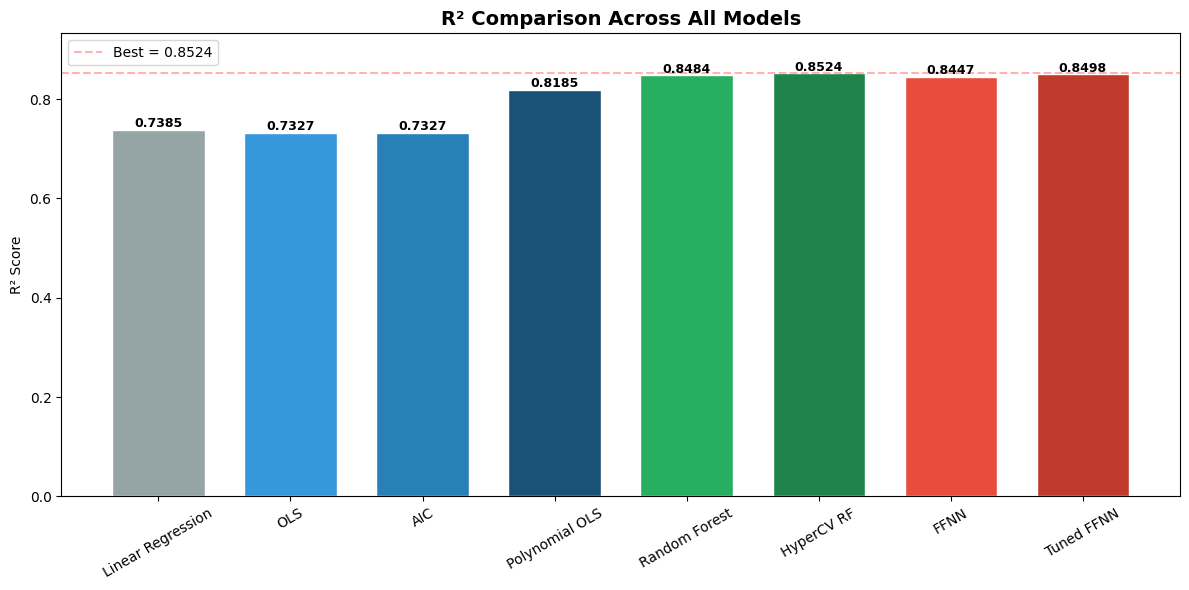

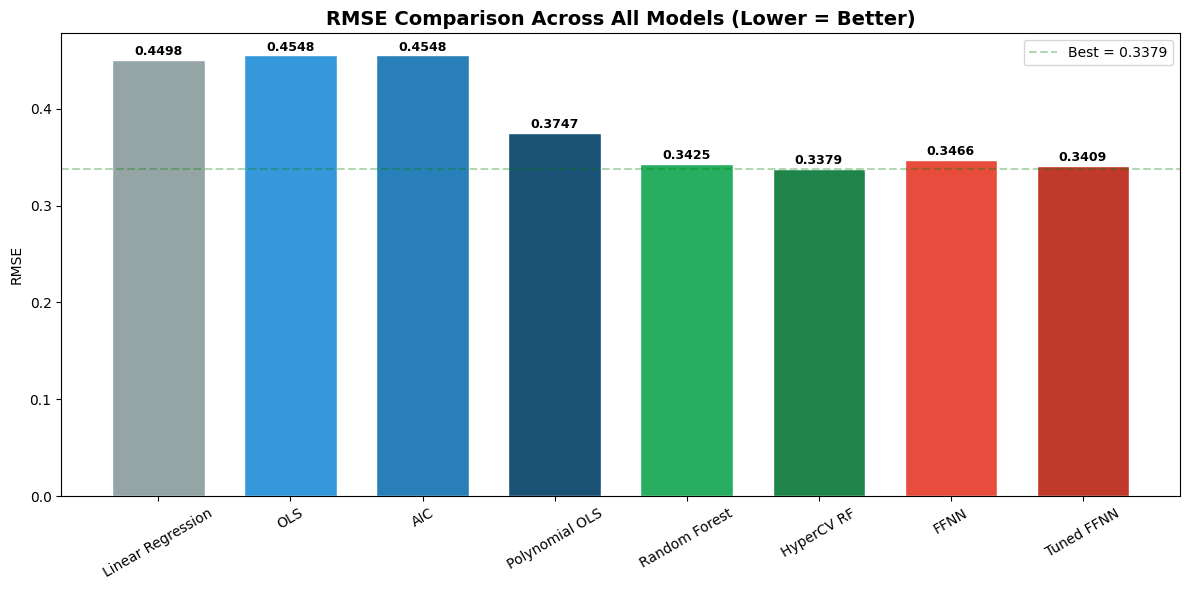

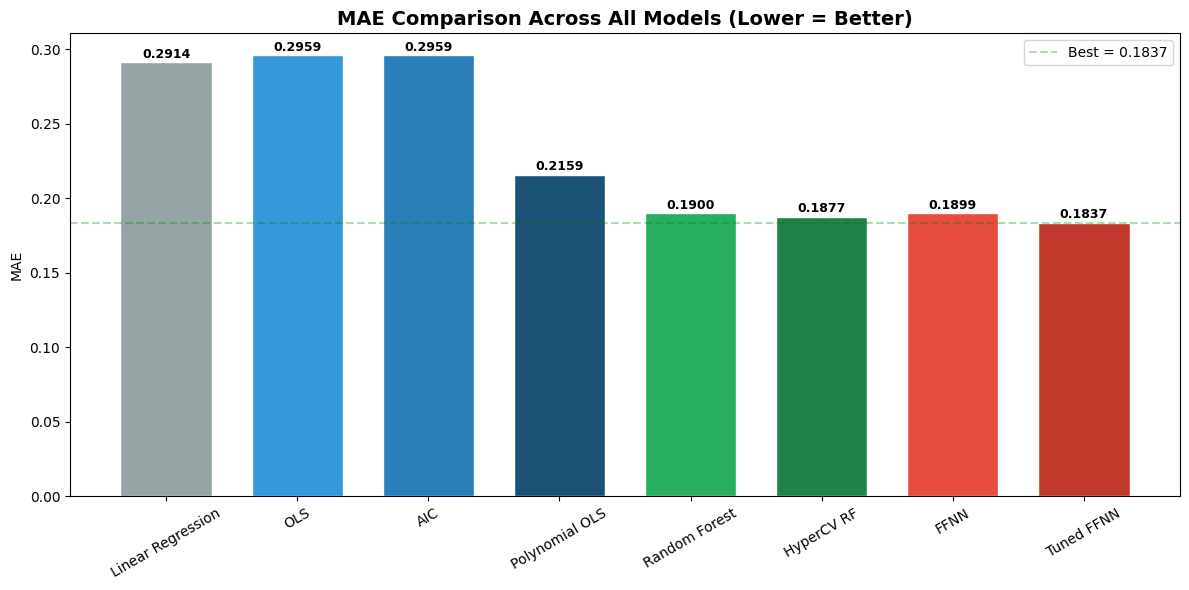

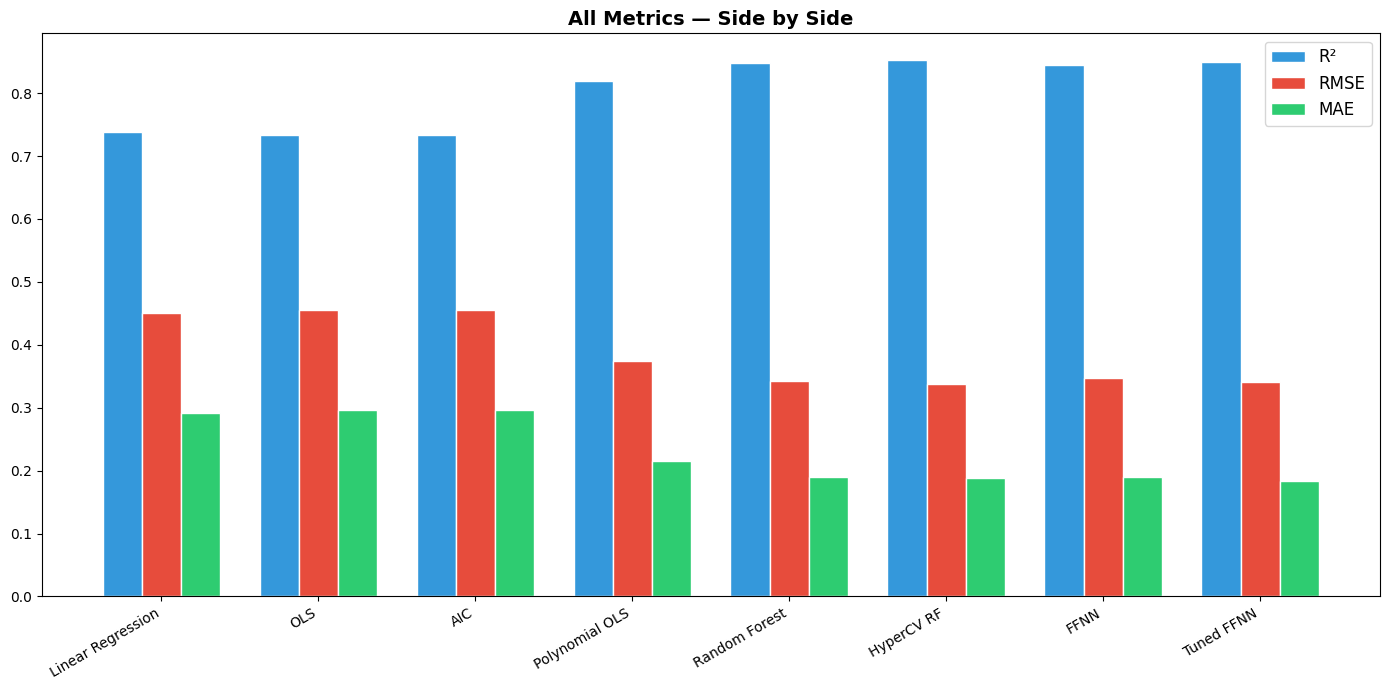

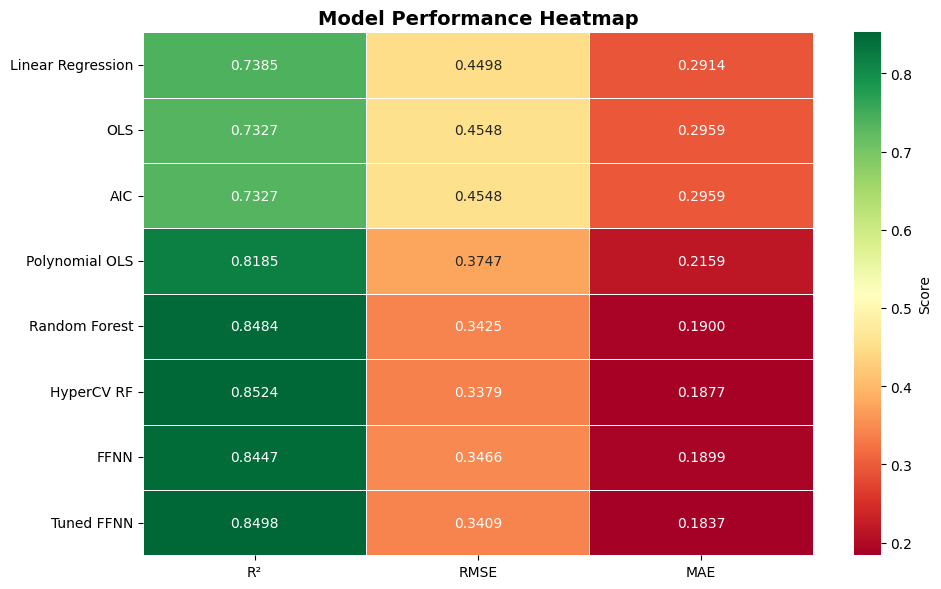

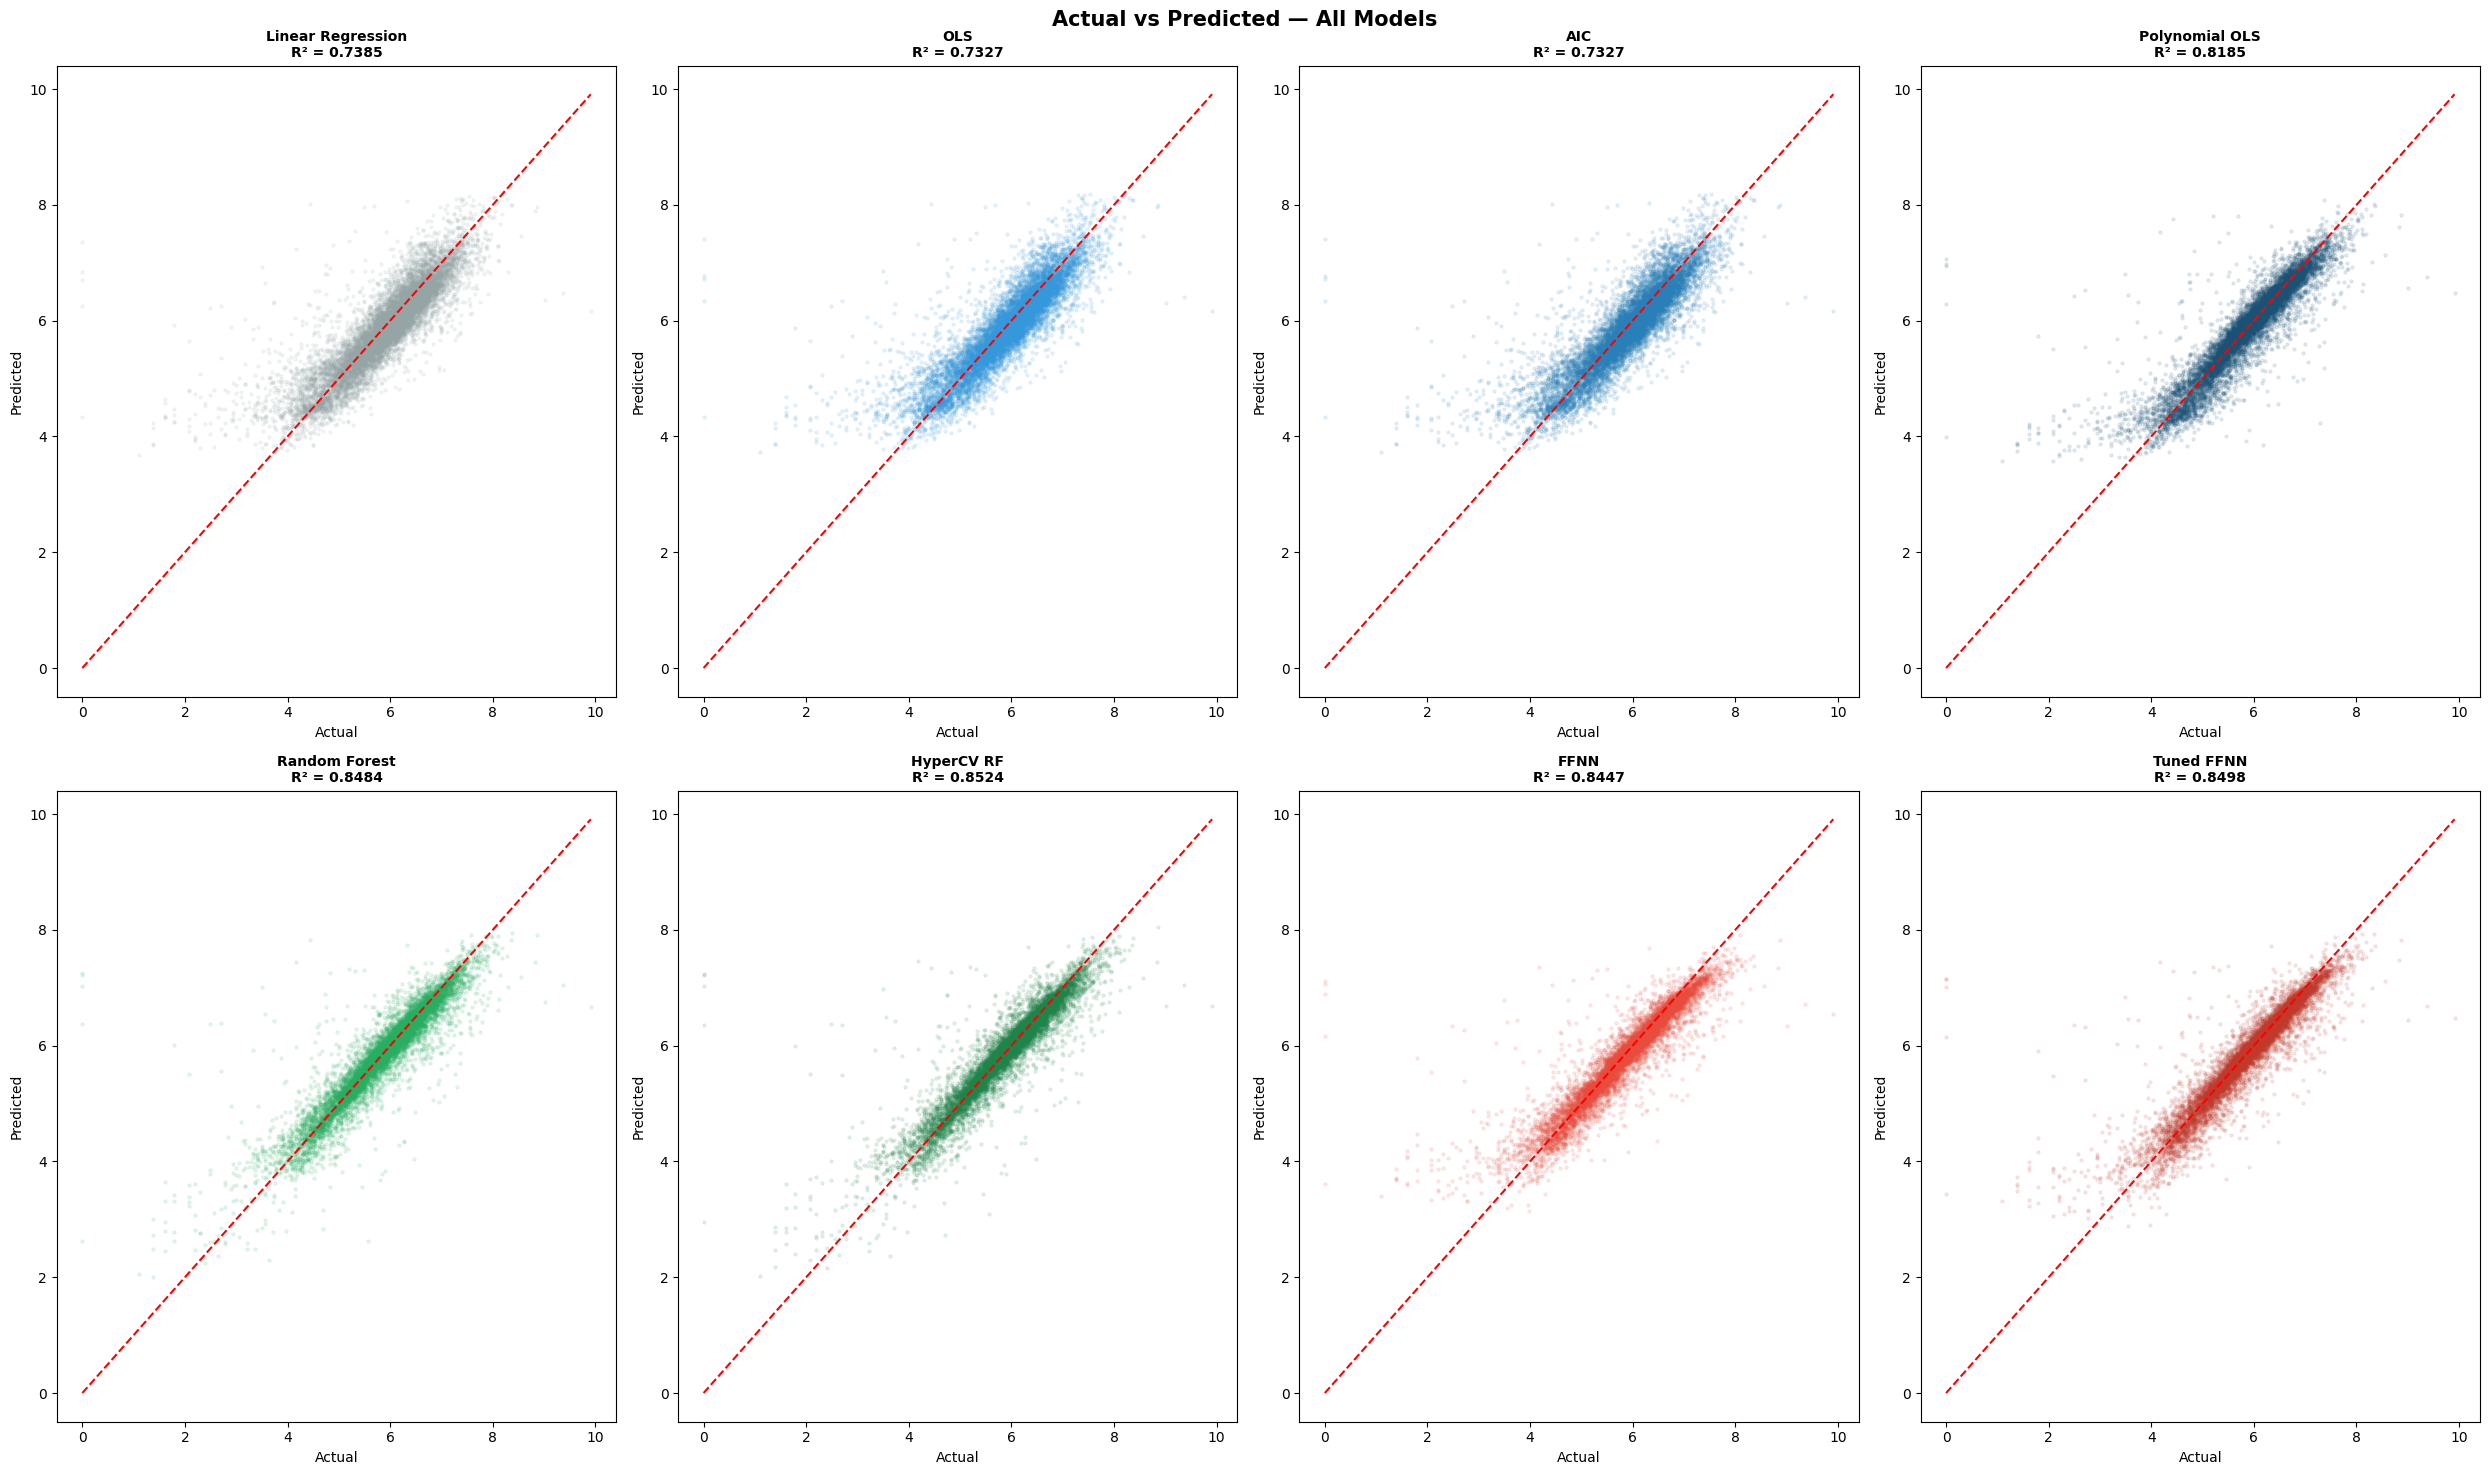

In [ ]:
# ══════════════════════════════════════════════════════════════
# MODEL COMPARISON CHARTS
# ══════════════════════════════════════════════════════════════

models = ['Linear Regression', 'OLS', 'AIC', 'Polynomial OLS',
          'Random Forest', 'HyperCV RF', 'FFNN', 'Tuned FFNN']
r2_scores  = [lr_r2, ols_r2, aic_r2, poly_r2, rf_r2, hyperr22, ffnn_r2, tuned_ffnn_r2]
mse_scores = [lr_mse, ols_mse, aic_mse, poly_mse, rf_mse, hypermse, ffnn_mse, tuned_ffnn_mse]
mae_scores = [lr_mae, ols_mae, aic_mae, poly_mae, rf_mae, hypermae, ffnn_mae, tuned_ffnn_mae]
rmse_scores = [np.sqrt(m) for m in mse_scores]

colors = ['#95a5a6', '#3498db', '#2980b9', '#1a5276',
          '#27ae60', '#1e8449', '#e74c3c', '#c0392b']

# ── 1. R² Comparison ──
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models, r2_scores, color=colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('R² Score')
ax.set_title('R² Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(r2_scores) + 0.08)
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=max(r2_scores), color='red', linestyle='--', alpha=0.3, label=f'Best = {max(r2_scores):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

# ── 2. RMSE Comparison ──
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models, rmse_scores, color=colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, rmse_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('RMSE Comparison Across All Models (Lower = Better)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=min(rmse_scores), color='green', linestyle='--', alpha=0.3, label=f'Best = {min(rmse_scores):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. MAE Comparison ──
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models, mae_scores, color=colors, edgecolor='white', width=0.7)
for bar, val in zip(bars, mae_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)
ax.set_ylabel('MAE')
ax.set_title('MAE Comparison Across All Models (Lower = Better)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.axhline(y=min(mae_scores), color='green', linestyle='--', alpha=0.3, label=f'Best = {min(mae_scores):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

# ── 4. All Metrics Side-by-Side ──
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width, r2_scores, width, label='R²', color='#3498db', edgecolor='white')
ax.bar(x, rmse_scores, width, label='RMSE', color='#e74c3c', edgecolor='white')
ax.bar(x + width, mae_scores, width, label='MAE', color='#2ecc71', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_title('All Metrics — Side by Side', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# ── 5. Heatmap ──
heatmap_df = pd.DataFrame({
    'R²': r2_scores, 'RMSE': rmse_scores, 'MAE': mae_scores
}, index=models)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Actual vs Predicted (all models) ──
all_preds = {
    'Linear Regression': lr_y_pred, 'OLS': ols_y_pred,
    'AIC': aic_y_pred, 'Polynomial OLS': poly_y_pred,
    'Random Forest': rf_y_pred, 'HyperCV RF': hypercv_ypred,
    'FFNN': ffnn_y_pred, 'Tuned FFNN': tuned_ffnn_y_pred,
}

fig, axes = plt.subplots(2, 4, figsize=(25, 15))
axes = axes.flatten()

for ax, (name, preds), color in zip(axes, all_preds.items(), colors):
    ax.scatter(y_test, preds, alpha=0.1, s=5, color=color)
    mn, mx = min(y_test.min(), preds.min()), max(y_test.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    r2 = r2_score(y_test, preds)
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

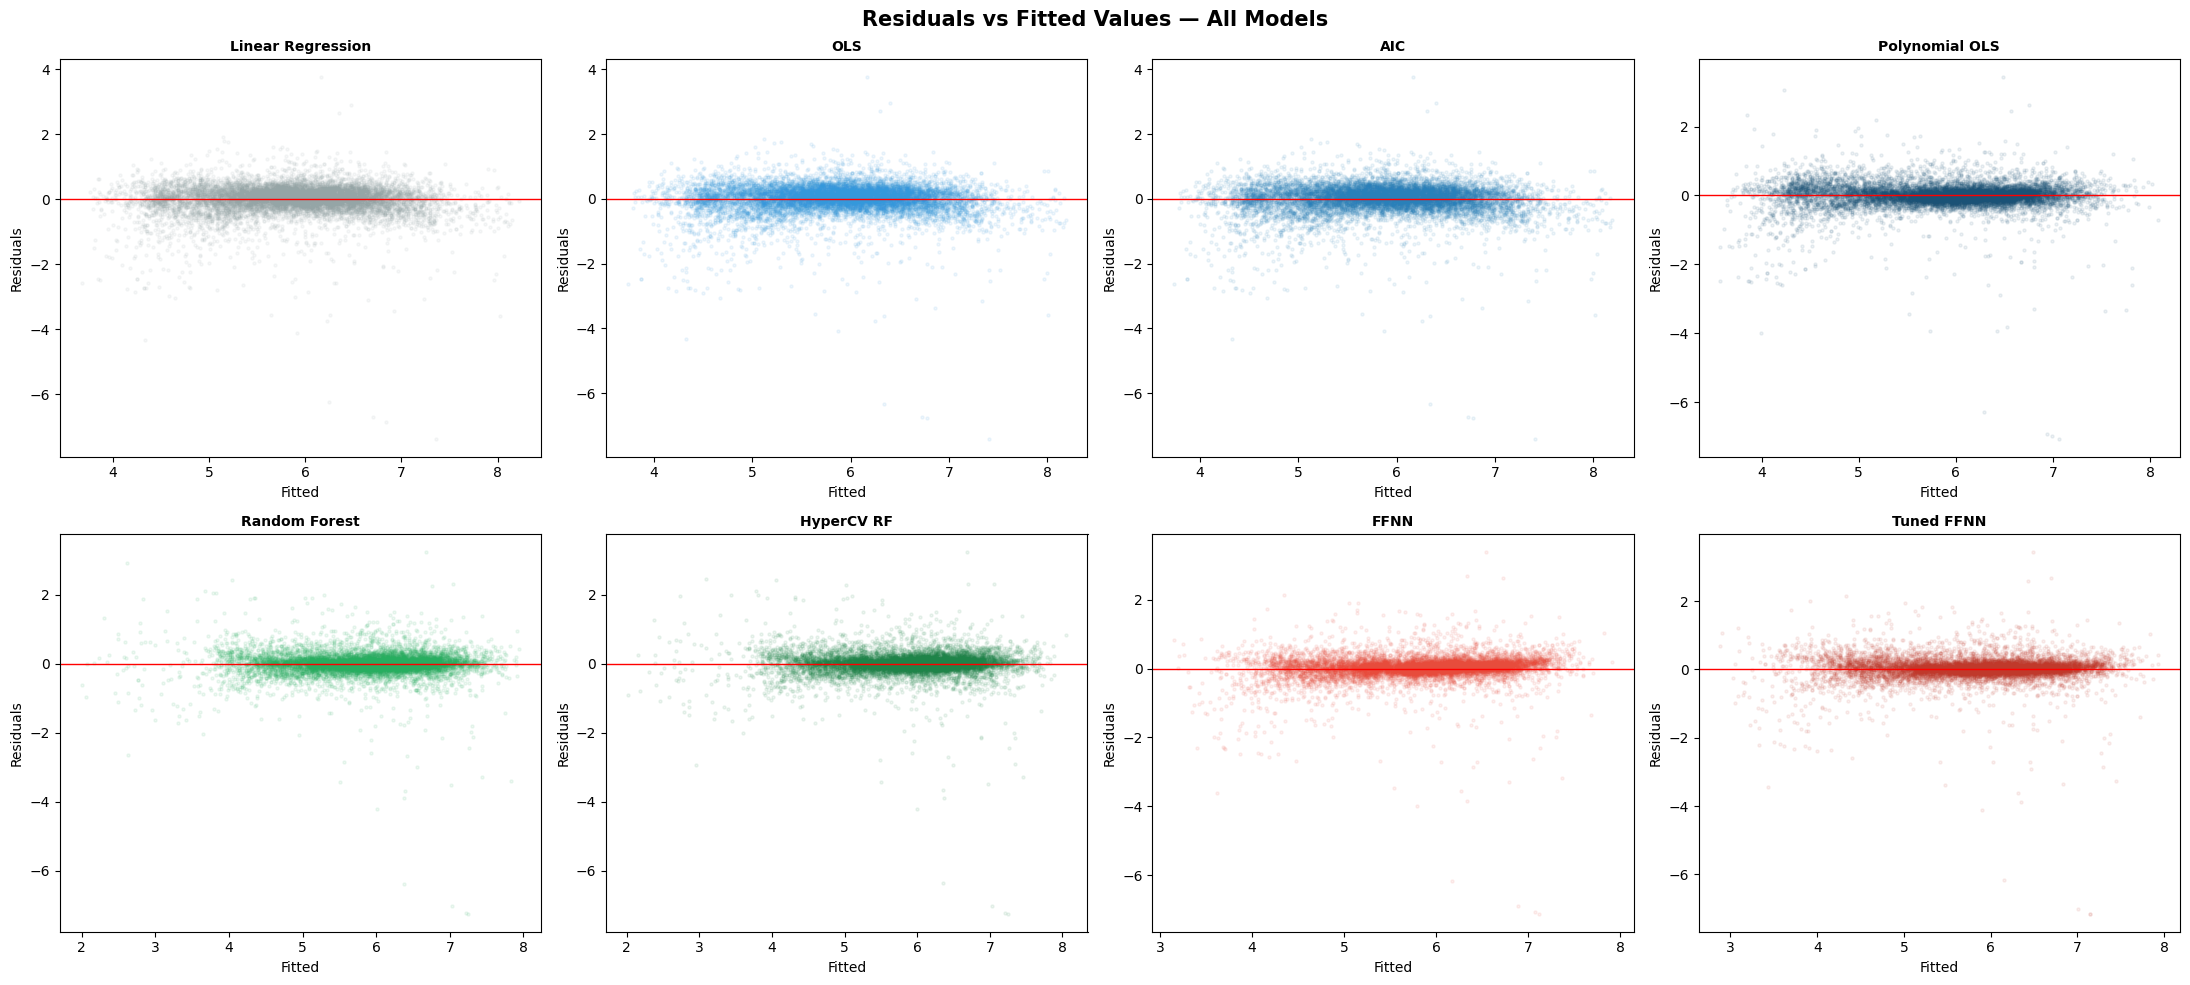

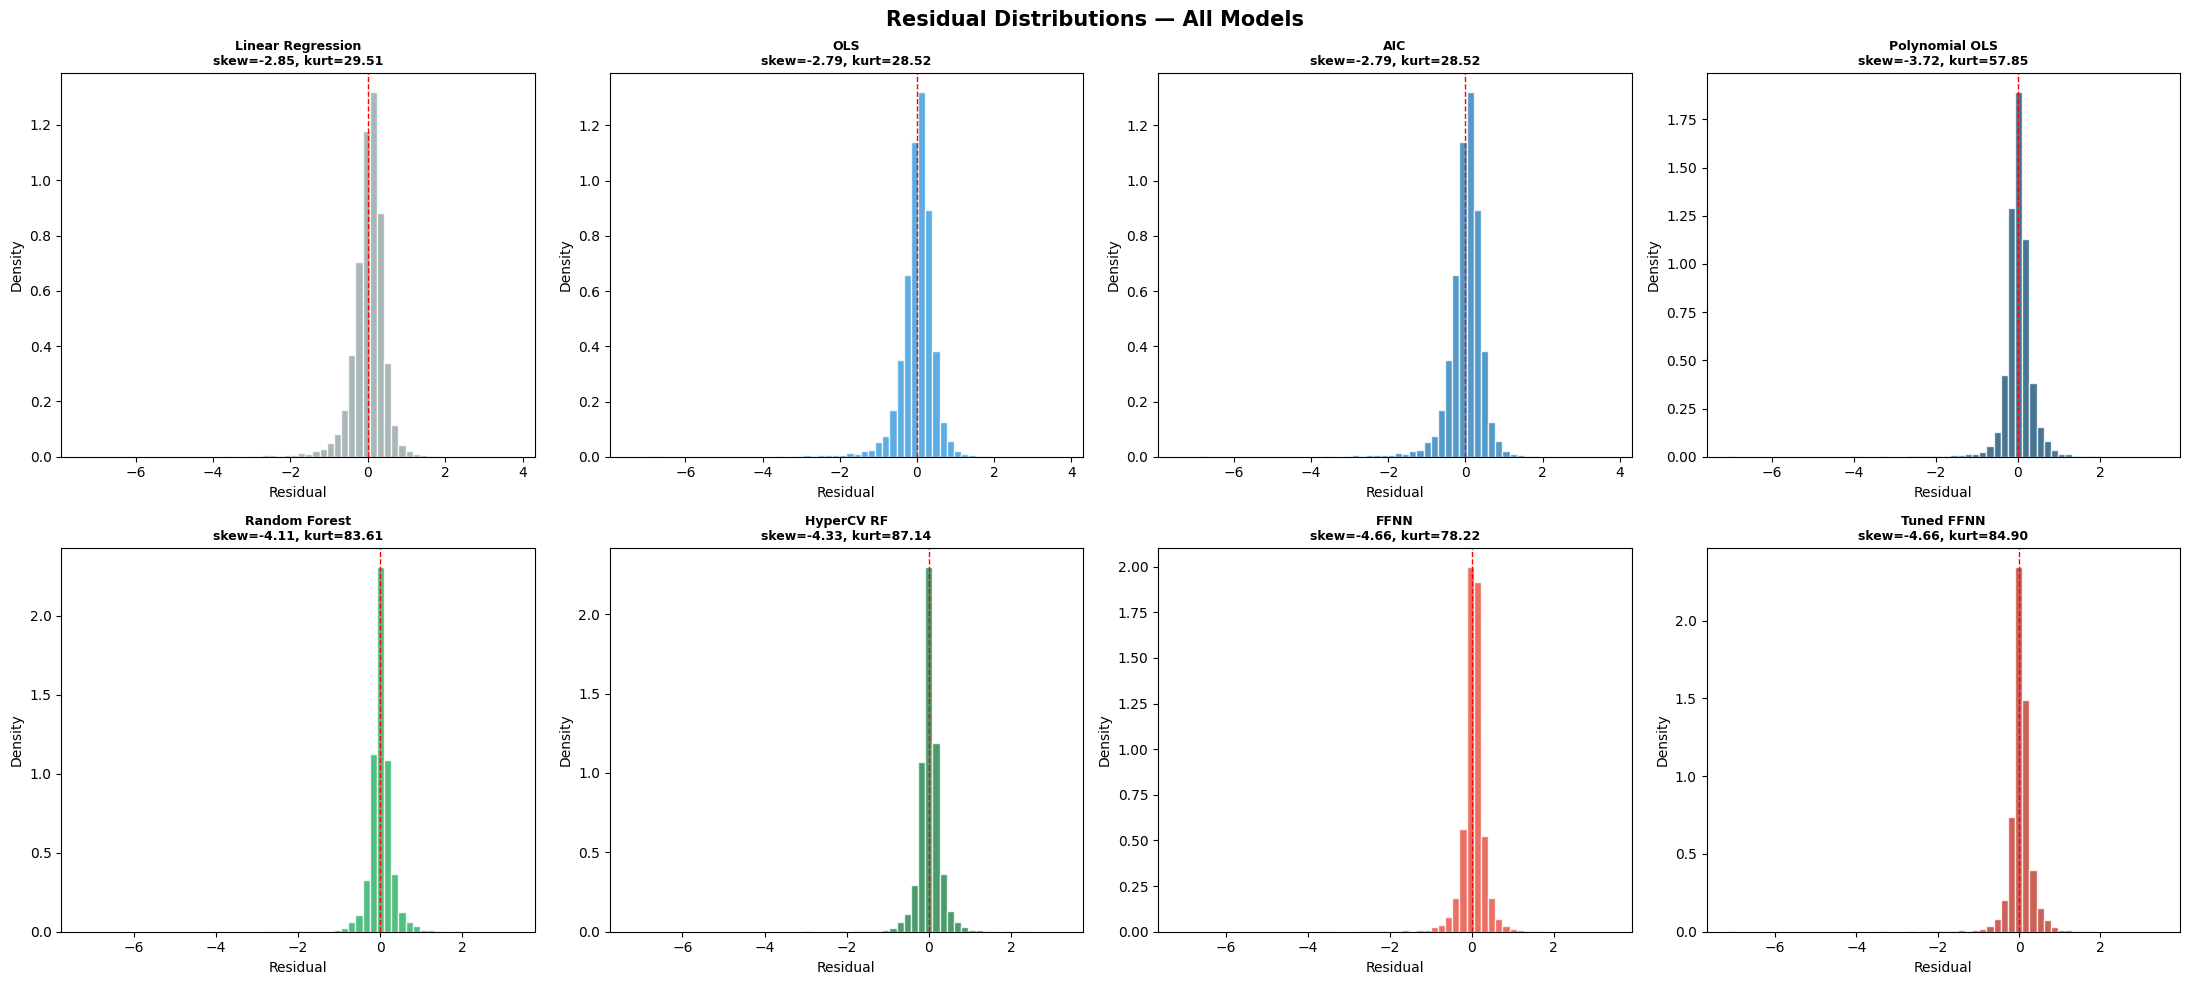

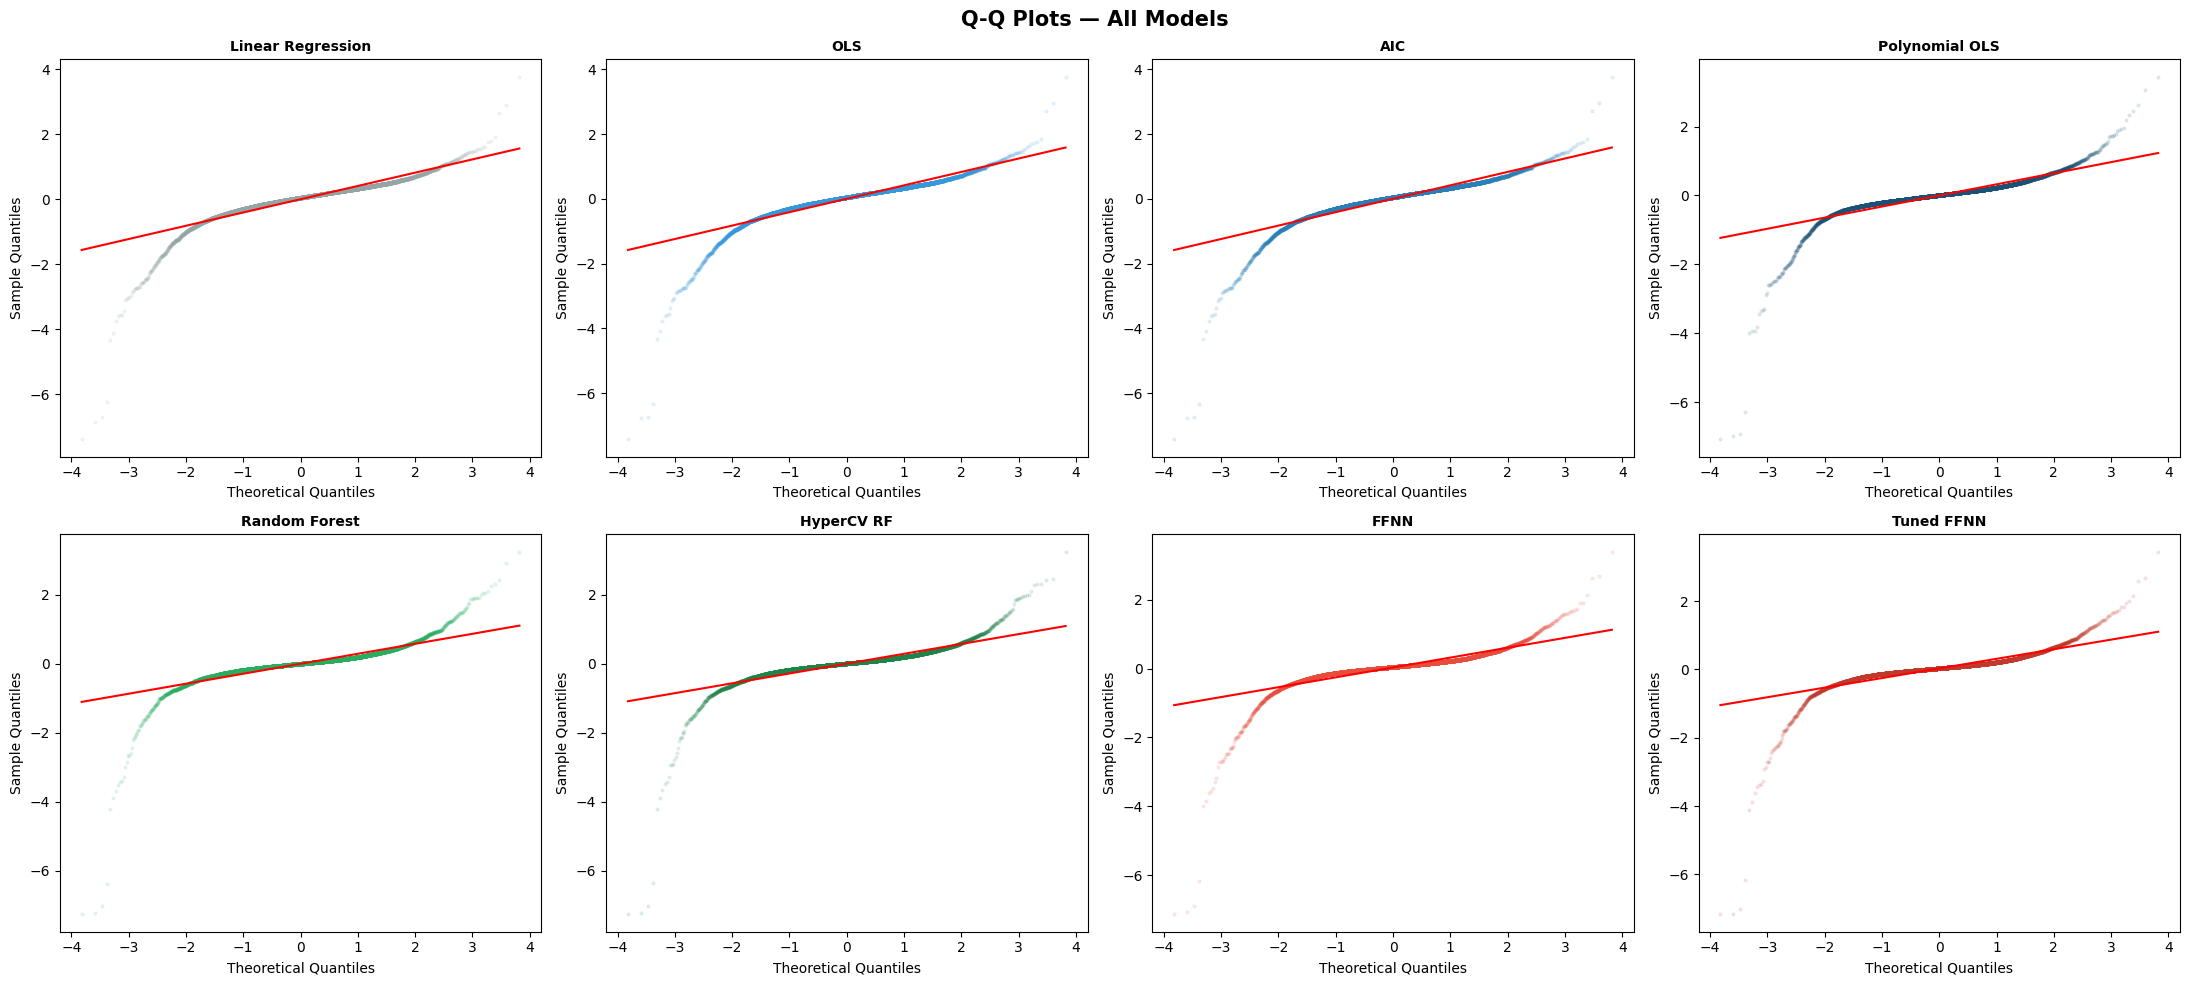

══════════════════════════════════════════════════════════════════════════════════════════
                     RESIDUAL ANALYSIS — SUMMARY
══════════════════════════════════════════════════════════════════════════════════════════
                   Mean Residual  Std Residual  Skewness  Kurtosis  Min Residual  Max Residual  % within ±1σ
Model                                                                                                       
Linear Regression         0.0024        0.4498   -2.8519   29.5084       -7.3608        3.7490       82.1959
OLS                       0.0013        0.4548   -2.7871   28.5206       -7.4056        3.7485       82.1284
AIC                       0.0013        0.4548   -2.7871   28.5206       -7.4056        3.7485       82.1284
Polynomial OLS            0.0006        0.3747   -3.7206   57.8517       -7.0596        3.4271       86.2348
Random Forest             0.0043        0.3425   -4.1086   83.6062       -7.2475        3.2363       85.8589
HyperC

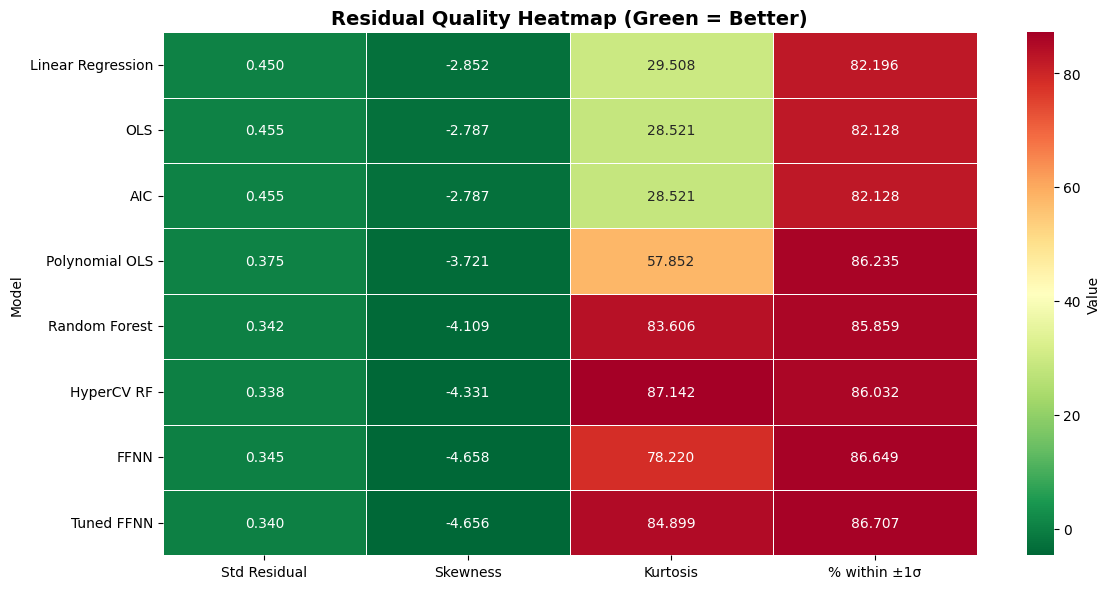

In [ ]:
# ══════════════════════════════════════════════════════════════
# RESIDUAL ANALYSIS — ALL MODELS
# ══════════════════════════════════════════════════════════════

all_models = {
    'Linear Regression': lr_y_pred,
    'OLS': ols_y_pred,
    'AIC': aic_y_pred,
    'Polynomial OLS': poly_y_pred,
    'Random Forest': rf_y_pred,
    'HyperCV RF': hypercv_ypred,
    'FFNN': ffnn_y_pred,
    'Tuned FFNN': tuned_ffnn_y_pred,
}

colors = ['#95a5a6', '#3498db', '#2980b9', '#1a5276',
          '#27ae60', '#1e8449', '#e74c3c', '#c0392b']

y_true = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# ── 1. Residuals vs Fitted (all models) ──
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (name, preds), color in zip(axes, all_models.items(), colors):
    preds = np.array(preds)
    residuals = y_true - preds
    ax.scatter(preds, residuals, alpha=0.08, s=5, color=color)
    ax.axhline(y=0, color='red', linewidth=1)
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Fitted')
    ax.set_ylabel('Residuals')

plt.suptitle('Residuals vs Fitted Values — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Residual Histograms (all models) ──
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (name, preds), color in zip(axes, all_models.items(), colors):
    preds = np.array(preds)
    residuals = y_true - preds
    ax.hist(residuals, bins=60, color=color, edgecolor='white', alpha=0.8, density=True)
    ax.axvline(x=0, color='red', linewidth=1, linestyle='--')
    ax.set_title(f'{name}\nskew={pd.Series(residuals).skew():.2f}, kurt={pd.Series(residuals).kurt():.2f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')

plt.suptitle('Residual Distributions — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Q-Q Plots (all models) ──
from scipy import stats

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (name, preds), color in zip(axes, all_models.items(), colors):
    preds = np.array(preds)
    residuals = y_true - preds
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax.plot(osm, osr, 'o', color=color, alpha=0.1, markersize=2)
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.suptitle('Q-Q Plots — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 4. Summary Stats Table ──
residual_stats = []
for name, preds in all_models.items():
    preds = np.array(preds)
    res = y_true - preds
    residual_stats.append({
        'Model': name,
        'Mean Residual': np.mean(res),
        'Std Residual': np.std(res),
        'Skewness': pd.Series(res).skew(),
        'Kurtosis': pd.Series(res).kurt(),
        'Min Residual': np.min(res),
        'Max Residual': np.max(res),
        '% within ±1σ': (np.abs(res) <= np.std(res)).mean() * 100,
    })

residual_df = pd.DataFrame(residual_stats).set_index('Model')
print('═' * 90)
print('                     RESIDUAL ANALYSIS — SUMMARY')
print('═' * 90)
print(residual_df.round(4).to_string())
print('═' * 90)

# ── 6. Residual Summary Heatmap ──
fig, ax = plt.subplots(figsize=(12, 6))
display_cols = ['Std Residual', 'Skewness', 'Kurtosis', '% within ±1σ']
sns.heatmap(residual_df[display_cols], annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Value'})
ax.set_title('Residual Quality Heatmap (Green = Better)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()